In [2]:
# === Cell 1: Mount Drive, install nnU-Net v2, set env vars ===

from google.colab import drive
drive.mount('/content/drive')

!pip install nnunetv2

import os

WORKSPACE = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace'
os.makedirs(os.path.join(WORKSPACE, 'nnUNet_raw'), exist_ok=True)
os.makedirs(os.path.join(WORKSPACE, 'nnUNet_preprocessed'), exist_ok=True)

for run_id in range(3):
    os.makedirs(os.path.join(WORKSPACE, f'nnUNet_results_run{run_id}'), exist_ok=True)

os.environ['nnUNet_raw'] = os.path.join(WORKSPACE, 'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(WORKSPACE, 'nnUNet_preprocessed')
# nnUNet_results will be set per-run in Cell 6; default to run0 for now
os.environ['nnUNet_results'] = os.path.join(WORKSPACE, 'nnUNet_results_run0')

print('nnUNet_raw:', os.environ['nnUNet_raw'])
print('nnUNet_preprocessed:', os.environ['nnUNet_preprocessed'])
print('nnUNet_results (default):', os.environ['nnUNet_results'])

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━

nnUNet_raw: /content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_raw
nnUNet_preprocessed: /content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_preprocessed
nnUNet_results (default): /content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_run0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import glob
zips = sorted(glob.glob('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/Reindexados-*.zip'))
print(f'Total zips: {len(zips)}')
for z in zips:
    print(f'  {z.split("/")[-1]}')

Mounted at /content/drive
Total zips: 22
  Reindexados-20260406T165204Z-1-001.zip
  Reindexados-20260406T165204Z-1-002.zip
  Reindexados-20260406T165204Z-1-003.zip
  Reindexados-20260406T165204Z-1-004.zip
  Reindexados-20260406T165204Z-1-005.zip
  Reindexados-20260406T165204Z-1-006.zip
  Reindexados-20260406T165204Z-1-007.zip
  Reindexados-20260406T165204Z-1-008.zip
  Reindexados-20260406T165204Z-1-009.zip
  Reindexados-20260406T165204Z-1-010.zip
  Reindexados-20260406T165204Z-1-011.zip
  Reindexados-20260406T165204Z-1-012.zip
  Reindexados-20260406T165204Z-1-013.zip
  Reindexados-20260406T165204Z-1-014.zip
  Reindexados-20260406T165204Z-1-015.zip
  Reindexados-20260406T165204Z-1-016.zip
  Reindexados-20260406T165204Z-1-017.zip
  Reindexados-20260406T165204Z-1-018.zip
  Reindexados-20260406T165204Z-1-019.zip
  Reindexados-20260406T165204Z-1-020.zip
  Reindexados-20260406T165204Z-1-021.zip
  Reindexados-20260406T165204Z-1-022.zip


In [ ]:
import cv2, glob, os
import pandas as pd

# Leer metadata
csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

# Buscar los .avi extraídos
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
avis = sorted(glob.glob(f'{videos_dir}/**/*.avi', recursive=True))
print(f'Total .avi encontrados: {len(avis)}')
print(f'Ejemplo path: {avis[0] if avis else "NINGUNO"}')

# Obtener frames totales y fps de cada video
video_info = []
for avi in avis[:10]:  # primero solo 10 para testear
    cap = cv2.VideoCapture(avi)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    name = os.path.basename(avi)
    video_info.append({'file': name, 'total_frames': total, 'fps': fps})

vi = pd.DataFrame(video_info)
print(f'\n=== PRIMEROS 10 VIDEOS ===')
print(vi.to_string())

In [3]:
import zipfile, glob, os

zips_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data'
out_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
os.makedirs(out_dir, exist_ok=True)

for zf in sorted(glob.glob(f'{zips_dir}/Reindexados-*.zip')):
    print(f'Extracting {os.path.basename(zf)}...')
    with zipfile.ZipFile(zf) as z:
        z.extractall(out_dir)

# Ver qué quedó
avis = sorted(glob.glob(f'{out_dir}/**/*.avi', recursive=True))
print(f'\nTotal .avi files: {len(avis)}')
for a in avis[:5]:
    print(f'  {a}')

Extracting Reindexados-20260406T165204Z-1-001.zip...
Extracting Reindexados-20260406T165204Z-1-002.zip...
Extracting Reindexados-20260406T165204Z-1-003.zip...
Extracting Reindexados-20260406T165204Z-1-004.zip...
Extracting Reindexados-20260406T165204Z-1-005.zip...
Extracting Reindexados-20260406T165204Z-1-006.zip...
Extracting Reindexados-20260406T165204Z-1-007.zip...
Extracting Reindexados-20260406T165204Z-1-008.zip...
Extracting Reindexados-20260406T165204Z-1-009.zip...
Extracting Reindexados-20260406T165204Z-1-010.zip...
Extracting Reindexados-20260406T165204Z-1-011.zip...
Extracting Reindexados-20260406T165204Z-1-012.zip...
Extracting Reindexados-20260406T165204Z-1-013.zip...
Extracting Reindexados-20260406T165204Z-1-014.zip...
Extracting Reindexados-20260406T165204Z-1-015.zip...
Extracting Reindexados-20260406T165204Z-1-016.zip...
Extracting Reindexados-20260406T165204Z-1-017.zip...
Extracting Reindexados-20260406T165204Z-1-018.zip...
Extracting Reindexados-20260406T165204Z-1-019.

In [ ]:
import shutil, glob, os

src = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos/Reindexados'
dst = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'

# Mover todos los .avi de Reindexados/ a videos/
for avi in glob.glob(f'{src}/*.avi'):
    dest = os.path.join(dst, os.path.basename(avi))
    if not os.path.exists(dest):
        shutil.move(avi, dest)

# Verificar
avis = glob.glob(f'{dst}/*.avi')
print(f'AVIs en videos/: {len(avis)}')

# Borrar carpeta vacía
if os.path.isdir(src) and len(os.listdir(src)) == 0:
    os.rmdir(src)
    print('Carpeta Reindexados/ eliminada')

In [4]:
import cv2, glob, os
import pandas as pd

# Leer metadata
csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

# Videos
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos/Reindexados'

# Info de TODOS los videos
video_info = []
for vid_id in sorted(df['video_id'].unique()):
    avi_path = f'{videos_dir}/{vid_id}.avi'
    if os.path.exists(avi_path):
        cap = cv2.VideoCapture(avi_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()

        labeled_frames = sorted(df[df['video_id']==vid_id]['frame_id'].tolist())
        video_info.append({
            'video_id': vid_id,
            'total_frames': total,
            'fps': fps,
            'duration_sec': round(total/fps, 1) if fps > 0 else 0,
            'n_labeled': len(labeled_frames),
            'labeled_frames': labeled_frames,
            'max_possible_r': min(labeled_frames[0], total - labeled_frames[-1] - 1) if labeled_frames else 0
        })
    else:
        print(f'MISSING: {avi_path}')

vi = pd.DataFrame(video_info)

print(f'=== RESUMEN ===')
print(f'Videos encontrados: {len(vi)}')
print(f'Total frames (todos videos): {vi["total_frames"].sum()}')
print(f'\n=== DURACION (segundos) ===')
print(vi['duration_sec'].describe())
print(f'\n=== FRAMES POR VIDEO ===')
print(vi['total_frames'].describe())
print(f'\n=== FPS ===')
print(vi['fps'].unique())
print(f'\n=== LABELED FRAMES POR VIDEO ===')
print(vi['n_labeled'].describe())
print(f'\n=== VIDEOS CON MENOS DE 50 FRAMES ===')
short = vi[vi['total_frames'] < 50]
print(f'{len(short)} videos')
if len(short) > 0:
    print(short[['video_id','total_frames','n_labeled','labeled_frames']].to_string())

print(f'\n=== PRIMEROS 15 VIDEOS (detalle) ===')
print(vi[['video_id','total_frames','fps','duration_sec','n_labeled','labeled_frames']].head(15).to_string())

=== RESUMEN ===
Videos encontrados: 234
Total frames (todos videos): 46637

=== DURACION (segundos) ===
count    234.000000
mean       6.637179
std        2.003159
min        0.500000
25%        5.200000
50%        7.350000
75%        8.475000
max        8.500000
Name: duration_sec, dtype: float64

=== FRAMES POR VIDEO ===
count    234.000000
mean     199.303419
std       60.409527
min       14.000000
25%      155.250000
50%      220.500000
75%      253.750000
max      256.000000
Name: total_frames, dtype: float64

=== FPS ===
[30.]

=== LABELED FRAMES POR VIDEO ===
count    234.000000
mean       4.136752
std        0.599083
min        1.000000
25%        4.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: n_labeled, dtype: float64

=== VIDEOS CON MENOS DE 50 FRAMES ===
5 videos
     video_id  total_frames  n_labeled      labeled_frames
129       131            29          5  [7, 8, 11, 14, 27]
156       158            14          4       [4, 7, 8, 13]
195       

In [5]:
import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

# Simular pools para cada radio
for r in [3, 5, 7, 10, 15, 20]:
    unlabeled_frames = set()
    for _, row in df.iterrows():
        vid = row['video_id']
        t = row['frame_id']
        total = vi[vi['video_id']==vid]['total_frames'].values[0]
        labeled_set = set(df[df['video_id']==vid]['frame_id'])
        for f in range(max(0, t-r), min(total, t+r+1)):
            if f not in labeled_set:
                unlabeled_frames.add((vid, f))
    print(f'r={r:2d}: {len(unlabeled_frames):,} frames unlabeled')

# Tambien: total unlabeled (todos los frames no anotados de todos los videos)
total_unlabeled = 0
for _, row in vi.iterrows():
    n_unlabeled = row['total_frames'] - row['n_labeled']
    total_unlabeled += n_unlabeled
print(f'ALL:  {total_unlabeled:,} frames unlabeled (total)')

# Porcentaje del total
print(f'\n=== COMO % DEL TOTAL UNLABELED ({total_unlabeled:,}) ===')
for r in [3, 5, 7, 10, 15, 20]:
    unlabeled_frames = set()
    for _, row in df.iterrows():
        vid = row['video_id']
        t = row['frame_id']
        total = vi[vi['video_id']==vid]['total_frames'].values[0]
        labeled_set = set(df[df['video_id']==vid]['frame_id'])
        for f in range(max(0, t-r), min(total, t+r+1)):
            if f not in labeled_set:
                unlabeled_frames.add((vid, f))
    pct = len(unlabeled_frames) / total_unlabeled * 100
    print(f'r={r:2d}: {len(unlabeled_frames):,} ({pct:.1f}%)')

r= 3: 4,852 frames unlabeled
r= 5: 7,806 frames unlabeled
r= 7: 10,543 frames unlabeled
r=10: 14,347 frames unlabeled
r=15: 19,761 frames unlabeled
r=20: 24,155 frames unlabeled
ALL:  45,669 frames unlabeled (total)

=== COMO % DEL TOTAL UNLABELED (45,669) ===
r= 3: 4,852 (10.6%)
r= 5: 7,806 (17.1%)
r= 7: 10,543 (23.1%)
r=10: 14,347 (31.4%)
r=15: 19,761 (43.3%)
r=20: 24,155 (52.9%)


In [6]:
import pandas as pd

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

# Para cada video: qué % de frames NO labeled cubre cada radio
print("=== VIDEOS DONDE r=10 CUBRE >80% DE FRAMES NO LABELED ===")
for _, v in vi.iterrows():
    vid = v['video_id']
    total = v['total_frames']
    labeled = set(df[df['video_id']==vid]['frame_id'])
    n_unlabeled_total = total - len(labeled)

    if n_unlabeled_total == 0:
        continue

    for r in [10, 15, 20]:
        pool = set()
        for t in labeled:
            for f in range(max(0, t-r), min(total, t+r+1)):
                if f not in labeled:
                    pool.add(f)
        pct = len(pool) / n_unlabeled_total * 100
        if r == 10 and pct > 80:
            print(f'  Video {vid}: {total} frames, {len(labeled)} labeled, r=10 cubre {pct:.0f}% unlabeled')

print(f'\n=== VIDEOS CON MENOS DE 50 FRAMES (detalle por radio) ===')
for _, v in vi[vi['total_frames'] < 50].iterrows():
    vid = v['video_id']
    total = v['total_frames']
    labeled = set(df[df['video_id']==vid]['frame_id'])
    n_unlabeled_total = total - len(labeled)

    coverages = []
    for r in [3, 5, 7, 10, 15, 20]:
        pool = set()
        for t in labeled:
            for f in range(max(0, t-r), min(total, t+r+1)):
                if f not in labeled:
                    pool.add(f)
        pct = len(pool) / n_unlabeled_total * 100 if n_unlabeled_total > 0 else 0
        coverages.append(f'r{r}={pct:.0f}%')

    print(f'  Video {vid}: {total} frames, {len(labeled)} labeled, unlabeled={n_unlabeled_total} | {" ".join(coverages)}')

print(f'\n=== DISTRIBUCION: % DE VIDEOS DONDE r=X CUBRE 100% UNLABELED ===')
for r in [3, 5, 7, 10, 15, 20]:
    n_full = 0
    for _, v in vi.iterrows():
        vid = v['video_id']
        total = v['total_frames']
        labeled = set(df[df['video_id']==vid]['frame_id'])
        n_unlabeled_total = total - len(labeled)
        if n_unlabeled_total == 0:
            n_full += 1
            continue
        pool = set()
        for t in labeled:
            for f in range(max(0, t-r), min(total, t+r+1)):
                if f not in labeled:
                    pool.add(f)
        if len(pool) >= n_unlabeled_total:
            n_full += 1
    print(f'  r={r:2d}: {n_full}/{len(vi)} videos ({n_full/len(vi)*100:.1f}%) tienen 100% cobertura')

=== VIDEOS DONDE r=10 CUBRE >80% DE FRAMES NO LABELED ===
  Video 127: 87 frames, 5 labeled, r=10 cubre 88% unlabeled
  Video 131: 29 frames, 5 labeled, r=10 cubre 100% unlabeled
  Video 158: 14 frames, 4 labeled, r=10 cubre 100% unlabeled
  Video 197: 36 frames, 4 labeled, r=10 cubre 100% unlabeled
  Video 206: 15 frames, 4 labeled, r=10 cubre 100% unlabeled
  Video 223: 29 frames, 4 labeled, r=10 cubre 100% unlabeled

=== VIDEOS CON MENOS DE 50 FRAMES (detalle por radio) ===
  Video 131: 29 frames, 5 labeled, unlabeled=24 | r3=58% r5=83% r7=100% r10=100% r15=100% r20=100%
  Video 158: 14 frames, 4 labeled, unlabeled=10 | r3=90% r5=100% r7=100% r10=100% r15=100% r20=100%
  Video 197: 36 frames, 4 labeled, unlabeled=32 | r3=50% r5=72% r7=84% r10=100% r15=100% r20=100%
  Video 206: 15 frames, 4 labeled, unlabeled=11 | r3=82% r5=100% r7=100% r10=100% r15=100% r20=100%
  Video 223: 29 frames, 4 labeled, unlabeled=25 | r3=56% r5=80% r7=88% r10=100% r15=100% r20=100%

=== DISTRIBUCION: % DE

In [7]:
import cv2, os
import pandas as pd
import numpy as np
from PIL import Image

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'

# ============================================
# 1. FRAME INDEXING: verificar si es 0-based o 1-based
# ============================================
print("=== 1. FRAME INDEXING TEST ===")
# Tomar 3 videos, extraer frame con index del CSV y con index-1,
# comparar con la máscara para ver cuál calza
test_rows = df.sample(3, random_state=42)
for _, row in test_rows.iterrows():
    vid = row['video_id']
    fid = row['frame_id']

    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')

    # Frame con index exacto del CSV
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret0, frame0 = cap.read()

    # Frame con index-1 (por si es 1-based)
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid - 1)
    ret1, frame1 = cap.read()

    cap.release()

    print(f'  Video {vid}, frame_id={fid}: read_at_{fid}={"OK" if ret0 else "FAIL"}, read_at_{fid-1}={"OK" if ret1 else "FAIL"}')
    if frame0 is not None:
        print(f'    frame shape: {frame0.shape}')

# ============================================
# 2. MASK PATHS: verificar que encontramos las máscaras
# ============================================
print("\n=== 2. MASK PATH VERIFICATION ===")
found = 0
missing = 0
missing_list = []
for _, row in df.iterrows():
    # target_dir tiene formato: ..\data\rotulos\anotacoes-tecgraf\batch-X\LABELER\video_frame
    td = row['target_dir']
    # Extraer la parte relativa después de anotacoes-tecgraf
    parts = td.replace('\\', '/').split('anotacoes-tecgraf/')
    if len(parts) == 2:
        rel = parts[1]
    else:
        rel = td.replace('\\', '/')

    mask_path = os.path.join(masks_root, rel, 'Mask.tif')
    if os.path.exists(mask_path):
        found += 1
    else:
        missing += 1
        if missing <= 5:
            missing_list.append(mask_path)

print(f'  Found: {found}/{len(df)}')
print(f'  Missing: {missing}/{len(df)}')
if missing_list:
    print(f'  Examples missing:')
    for m in missing_list:
        print(f'    {m}')

# Mostrar estructura real de masks_root
print(f'\n  Contenido de masks_root:')
if os.path.exists(masks_root):
    for item in sorted(os.listdir(masks_root))[:10]:
        print(f'    {item}')
else:
    print(f'    CARPETA NO EXISTE: {masks_root}')
    # Probar variantes
    alt = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos'
    if os.path.exists(alt):
        print(f'    Contenido de {alt}:')
        for item in sorted(os.listdir(alt)):
            print(f'      {item}')

# ============================================
# 3. SPLIT BALANCE ANALYSIS
# ============================================
print("\n=== 3. SPLIT BALANCE (simulación 70/15/15 por paciente) ===")
from sklearn.model_selection import train_test_split

patient_info = df.groupby('paciente_id').agg(
    n_frames=('video_frame', 'count'),
    n_videos=('video_id', 'nunique'),
    fonte=('fonte_dados', 'first')
).reset_index()

patients = patient_info['paciente_id'].values

# Split: primero train vs rest, luego rest en val y test
train_p, rest_p = train_test_split(patients, test_size=0.30, random_state=42)
val_p, test_p = train_test_split(rest_p, test_size=0.50, random_state=42)

for name, pats in [('Train', train_p), ('Val', val_p), ('Test', test_p)]:
    subset = df[df['paciente_id'].isin(pats)]
    pi = patient_info[patient_info['paciente_id'].isin(pats)]
    n_heavy = pi[pi['fonte']=='Pacientes'].shape[0]
    n_light = pi[pi['fonte']=='video100'].shape[0]
    print(f'  {name:5s}: {len(pats):3d} patients ({n_heavy} heavy + {n_light} light), '
          f'{subset["video_id"].nunique():3d} videos, {len(subset):3d} frames')

# Check: any patient overlap?
assert len(set(train_p) & set(val_p)) == 0
assert len(set(train_p) & set(test_p)) == 0
assert len(set(val_p) & set(test_p)) == 0
print(f'  No patient overlap: OK')

# ============================================
# 4. VIDEO RESOLUTION CHECK
# ============================================
print("\n=== 4. VIDEO RESOLUTION (sample of 10) ===")
resolutions = set()
for vid_id in [1, 10, 50, 100, 101, 150, 200, 220, 230, 236]:
    avi = f'{videos_dir}/{vid_id}.avi'
    if os.path.exists(avi):
        cap = cv2.VideoCapture(avi)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        resolutions.add((w, h))
        print(f'  Video {vid_id}: {w}x{h}')
print(f'  Unique resolutions: {resolutions}')

# ============================================
# 5. MASK RESOLUTION AND FORMAT (if found)
# ============================================
print("\n=== 5. MASK FORMAT (first 3 found) ===")
checked = 0
for _, row in df.iterrows():
    td = row['target_dir']
    parts = td.replace('\\', '/').split('anotacoes-tecgraf/')
    if len(parts) == 2:
        rel = parts[1]
    else:
        continue
    mask_path = os.path.join(masks_root, rel, 'Mask.tif')
    if os.path.exists(mask_path):
        m = Image.open(mask_path)
        arr = np.array(m)
        print(f'  {row["video_frame"]}: size={m.size}, mode={m.mode}, unique={np.unique(arr)}, dtype={arr.dtype}')
        checked += 1
        if checked >= 3:
            break

=== 1. FRAME INDEXING TEST ===
  Video 223, frame_id=10: read_at_10=FAIL, read_at_9=FAIL
  Video 150, frame_id=109: read_at_109=FAIL, read_at_108=FAIL
  Video 179, frame_id=184: read_at_184=FAIL, read_at_183=FAIL

=== 2. MASK PATH VERIFICATION ===
  Found: 968/968
  Missing: 0/968

  Contenido de masks_root:
    Planilha Rotulagem Cervical - INCA.xlsx
    Protocolo - Anotações.docx
    atribuicoes-1.xlsx
    atribuicoes-2.xlsx
    atribuicoes-3.xlsx
    atribuicoes-4.xlsx
    atribuicoes-5.xlsx
    batch-1
    batch-2
    batch-3

=== 3. SPLIT BALANCE (simulación 70/15/15 por paciente) ===
  Train:  80 patients (9 heavy + 71 light), 147 videos, 612 frames
  Val  :  17 patients (3 heavy + 14 light),  39 videos, 155 frames
  Test :  18 patients (3 heavy + 15 light),  48 videos, 201 frames
  No patient overlap: OK

=== 4. VIDEO RESOLUTION (sample of 10) ===
  Unique resolutions: set()

=== 5. MASK FORMAT (first 3 found) ===
  v100_f10: size=(1024, 1024), mode=L, unique=[  0 255], dtype=

In [10]:
import cv2, os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'

# === 1. FRAME INDEXING ===
print("=== 1. FRAME INDEXING TEST ===")
test_rows = df.sample(3, random_state=42)
for _, row in test_rows.iterrows():
    vid = row['video_id']
    fid = row['frame_id']
    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')
    print(f'  Video {vid}: isOpened={cap.isOpened()}, total={int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}')
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret0, _ = cap.read()
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid - 1)
    ret1, _ = cap.read()
    cap.release()
    print(f'    frame_id={fid}: at_{fid}={"OK" if ret0 else "FAIL"}, at_{fid-1}={"OK" if ret1 else "FAIL"}')

# === 2. SPLIT BALANCE ===
print("\n=== 2. SPLIT BALANCE ===")
patient_info = df.groupby('paciente_id').agg(
    n_frames=('video_frame', 'count'),
    n_videos=('video_id', 'nunique'),
    fonte=('fonte_dados', 'first')
).reset_index()

patients = patient_info['paciente_id'].values
train_p, rest_p = train_test_split(patients, test_size=0.30, random_state=42)
val_p, test_p = train_test_split(rest_p, test_size=0.50, random_state=42)

for name, pats in [('Train', train_p), ('Val', val_p), ('Test', test_p)]:
    subset = df[df['paciente_id'].isin(pats)]
    pi = patient_info[patient_info['paciente_id'].isin(pats)]
    print(f'  {name:5s}: {len(pats):3d} patients, {subset["video_id"].nunique():3d} videos, {len(subset):3d} frames')

# === 3. VIDEO RESOLUTION ===
print("\n=== 3. VIDEO RESOLUTION ===")
resolutions = {}
for vid_id in [1, 10, 50, 100, 101, 150, 200, 220, 230, 236]:
    avi = f'{videos_dir}/{vid_id}.avi'
    if os.path.exists(avi):
        cap = cv2.VideoCapture(avi)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        res = f'{w}x{h}'
        resolutions[res] = resolutions.get(res, 0) + 1
        print(f'  Video {vid_id}: {res}')
print(f'  Unique: {resolutions}')

=== 1. FRAME INDEXING TEST ===
  Video 223: isOpened=True, total=29
    frame_id=10: at_10=OK, at_9=OK
  Video 150: isOpened=True, total=199
    frame_id=109: at_109=OK, at_108=OK
  Video 179: isOpened=True, total=256
    frame_id=184: at_184=OK, at_183=OK

=== 2. SPLIT BALANCE ===
  Train:  80 patients, 147 videos, 612 frames
  Val  :  17 patients,  39 videos, 155 frames
  Test :  18 patients,  48 videos, 201 frames

=== 3. VIDEO RESOLUTION ===
  Video 1: 512x512
  Video 10: 1024x1024
  Video 50: 1024x1024
  Video 100: 1024x1024
  Video 101: 1024x1024
  Video 150: 1024x1024
  Video 200: 1024x1024
  Video 220: 1024x1024
  Video 230: 1024x1024
  Video 236: 1024x1024
  Unique: {'512x512': 1, '1024x1024': 9}


In [11]:
import cv2, os
import pandas as pd

videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
df = pd.read_csv('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv')

resolutions = {}
non_standard = []
for vid_id in sorted(df['video_id'].unique()):
    avi = f'{videos_dir}/{vid_id}.avi'
    cap = cv2.VideoCapture(avi)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    res = f'{w}x{h}'
    resolutions[res] = resolutions.get(res, [])
    resolutions[res].append(vid_id)
    if res != '1024x1024':
        non_standard.append((vid_id, res))

print("=== RESOLUCION POR VIDEO ===")
for res, vids in resolutions.items():
    print(f'  {res}: {len(vids)} videos')

if non_standard:
    print(f'\n=== VIDEOS NO-1024x1024 ===')
    for vid, res in non_standard:
        n_labeled = len(df[df['video_id']==vid])
        patient = df[df['video_id']==vid]['paciente_id'].values[0]
        print(f'  Video {vid}: {res}, paciente {patient}, {n_labeled} labeled frames')

=== RESOLUCION POR VIDEO ===
  512x512: 27 videos
  1024x1024: 207 videos

=== VIDEOS NO-1024x1024 ===
  Video 1: 512x512, paciente 16, 5 labeled frames
  Video 2: 512x512, paciente 17, 4 labeled frames
  Video 5: 512x512, paciente 20, 4 labeled frames
  Video 7: 512x512, paciente 22, 4 labeled frames
  Video 8: 512x512, paciente 23, 4 labeled frames
  Video 25: 512x512, paciente 40, 4 labeled frames
  Video 27: 512x512, paciente 42, 4 labeled frames
  Video 37: 512x512, paciente 52, 4 labeled frames
  Video 43: 512x512, paciente 58, 4 labeled frames
  Video 49: 512x512, paciente 64, 4 labeled frames
  Video 52: 512x512, paciente 67, 4 labeled frames
  Video 55: 512x512, paciente 70, 4 labeled frames
  Video 58: 512x512, paciente 73, 4 labeled frames
  Video 60: 512x512, paciente 75, 4 labeled frames
  Video 62: 512x512, paciente 77, 4 labeled frames
  Video 86: 512x512, paciente 101, 4 labeled frames
  Video 87: 512x512, paciente 102, 3 labeled frames
  Video 88: 512x512, paciente 103

In [12]:
from PIL import Image
import os
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv')
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'

# Check masks de videos 512x512
vids_512 = [1, 2, 5, 86, 87]
for vid in vids_512:
    row = df[df['video_id']==vid].iloc[0]
    td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
    mask_path = os.path.join(masks_root, td, 'Mask.tif')
    if os.path.exists(mask_path):
        m = Image.open(mask_path)
        print(f'  Video {vid} (512x512): mask size = {m.size}')

  Video 1 (512x512): mask size = (512, 512)
  Video 2 (512x512): mask size = (512, 512)
  Video 5 (512x512): mask size = (512, 512)
  Video 86 (512x512): mask size = (512, 512)
  Video 87 (512x512): mask size = (512, 512)


In [13]:
import pandas as pd
import numpy as np
import json, os
from sklearn.model_selection import train_test_split

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Info por paciente
patient_info = df.groupby('paciente_id').agg(
    n_frames=('video_frame', 'count'),
    n_videos=('video_id', 'nunique')
).reset_index()

patients = patient_info['paciente_id'].values

# Paso 1: 80% trainval / 20% test (por paciente)
trainval_p, test_p = train_test_split(patients, test_size=0.20, random_state=42)

# Paso 2: del 80%, sacar validación (~18% del trainval ≈ 15% del total)
train_p, val_p = train_test_split(trainval_p, test_size=0.18, random_state=42)

# Resultados
split_map = {}
for p in train_p: split_map[int(p)] = 'train'
for p in val_p: split_map[int(p)] = 'val'
for p in test_p: split_map[int(p)] = 'test'

print("=== SPLIT POR PACIENTE ===")
for name, pats in [('Train', train_p), ('Val', val_p), ('Test', test_p)]:
    subset = df[df['paciente_id'].isin(pats)]
    print(f'  {name:5s}: {len(pats):3d} pacientes, {subset["video_id"].nunique():3d} videos, {len(subset):3d} frames')

total_frames = len(df)
for name, pats in [('Train', train_p), ('Val', val_p), ('Test', test_p)]:
    n = len(df[df['paciente_id'].isin(pats)])
    print(f'  {name:5s}: {n/total_frames*100:.1f}%')

# Verificar no overlap
assert len(set(train_p) & set(val_p)) == 0
assert len(set(train_p) & set(test_p)) == 0
assert len(set(val_p) & set(test_p)) == 0
print('\n  No patient overlap: OK')

# Guardar
split_info = {
    'train_patients': sorted([int(p) for p in train_p]),
    'val_patients': sorted([int(p) for p in val_p]),
    'test_patients': sorted([int(p) for p in test_p]),
}
with open(f'{OUTPUT_DIR}/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print(f'\nGuardado en {OUTPUT_DIR}/split_info.json')

=== SPLIT POR PACIENTE ===
  Train:  75 pacientes, 128 videos, 535 frames
  Val  :  17 pacientes,  42 videos, 170 frames
  Test :  23 pacientes,  64 videos, 263 frames
  Train: 55.3%
  Val  : 17.6%
  Test : 27.2%

  No patient overlap: OK

Guardado en /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/split_info.json


In [14]:
# Buscar un seed que dé proporciones más cercanas a 65/15/20
best_seed = None
best_diff = 999

for seed in range(200):
    tv, te = train_test_split(patients, test_size=0.20, random_state=seed)
    tr, va = train_test_split(tv, test_size=0.18, random_state=seed)

    tr_pct = len(df[df['paciente_id'].isin(tr)]) / len(df) * 100
    va_pct = len(df[df['paciente_id'].isin(va)]) / len(df) * 100
    te_pct = len(df[df['paciente_id'].isin(te)]) / len(df) * 100

    # Queremos ~65/15/20
    diff = abs(tr_pct - 65) + abs(va_pct - 15) + abs(te_pct - 20)

    if diff < best_diff:
        best_diff = diff
        best_seed = seed
        best_split = (tr_pct, va_pct, te_pct, len(tr), len(va), len(te),
                      len(df[df['paciente_id'].isin(tr)]),
                      len(df[df['paciente_id'].isin(va)]),
                      len(df[df['paciente_id'].isin(te)]))

print(f'Best seed: {best_seed}')
print(f'Train: {best_split[3]} pacientes, {best_split[6]} frames ({best_split[0]:.1f}%)')
print(f'Val:   {best_split[4]} pacientes, {best_split[7]} frames ({best_split[1]:.1f}%)')
print(f'Test:  {best_split[5]} pacientes, {best_split[8]} frames ({best_split[2]:.1f}%)')

Best seed: 110
Train: 75 pacientes, 634 frames (65.5%)
Val:   17 pacientes, 140 frames (14.5%)
Test:  23 pacientes, 194 frames (20.0%)


In [15]:
import pandas as pd
import numpy as np
import json, os
from sklearn.model_selection import train_test_split

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)

patients = df.groupby('paciente_id')['video_frame'].count().reset_index()['paciente_id'].values

trainval_p, test_p = train_test_split(patients, test_size=0.20, random_state=110)
train_p, val_p = train_test_split(trainval_p, test_size=0.18, random_state=110)

split_map = {}
for p in train_p: split_map[int(p)] = 'train'
for p in val_p: split_map[int(p)] = 'val'
for p in test_p: split_map[int(p)] = 'test'

for name, pats in [('Train', train_p), ('Val', val_p), ('Test', test_p)]:
    subset = df[df['paciente_id'].isin(pats)]
    pct = len(subset)/len(df)*100
    print(f'{name:5s}: {len(pats):3d} pacientes, {subset["video_id"].nunique():3d} videos, {len(subset):3d} frames ({pct:.1f}%)')

assert len(set(train_p) & set(val_p)) == 0
assert len(set(train_p) & set(test_p)) == 0
assert len(set(val_p) & set(test_p)) == 0
print('No patient overlap: OK')

split_info = {
    'train_patients': sorted([int(p) for p in train_p]),
    'val_patients': sorted([int(p) for p in val_p]),
    'test_patients': sorted([int(p) for p in test_p]),
}
with open(f'{OUTPUT_DIR}/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print(f'Guardado en {OUTPUT_DIR}/split_info.json')

Train:  75 pacientes, 156 videos, 634 frames (65.5%)
Val  :  17 pacientes,  33 videos, 140 frames (14.5%)
Test :  23 pacientes,  45 videos, 194 frames (20.0%)
No patient overlap: OK
Guardado en /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/split_info.json


In [18]:
readme = """# INCA Dataset — Preparación para validación externa
# Generado el: 2026-04-06
# Notebook: 03_inca_preparation.ipynb

## Fuente
- 236 videos VFSS del INCA (Drive compartido por Vinícius)
- 968 frames rotulados, 115 pacientes, 234 videos con labels
- Máscaras binarias de vértebras cervicales C2-C4
- 5 anotadores (AM, BB, CS, VC, VR), modo unión

## Split (seed=110, por paciente, 80/20 → train+val/test)
- Train: 75 pacientes, 156 videos, 634 frames (65.5%)
- Val:   17 pacientes,  33 videos, 140 frames (14.5%)
- Test:  23 pacientes,  45 videos, 194 frames (20.0%)
- Sin overlap de pacientes entre splits

## Resoluciones
- 207 videos: 1024x1024 (máscaras 1024x1024)
- 27 videos: 512x512 (máscaras 512x512)
- Pipeline resize a 320x320

## Videos
- FPS: 30
- Duración: 0.5-8.5 seg (media 6.6 seg)
- Frames por video: 14-256 (media 199)
- Solo vista lateral (sin cambio AP)

## Pools unlabeled (por radio temporal, por video)
- r=3:  4,852 frames (10.6% del total unlabeled)
- r=5:  7,806 (17.1%)
- r=7:  10,543 (23.1%)
- r=10: 14,347 (31.4%)
- r=15: 19,761 (43.3%)
- r=20: 24,155 (52.9%)
- ALL:  45,669 (100%)
"""

with open(f'{OUTPUT_DIR}/README.md', 'w') as f:
    f.write(readme)
print('README guardado')

README guardado


In [19]:
import cv2, os, json, shutil
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

# Cargar split
with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

split_map = {}
for p in split_info['train_patients']: split_map[p] = 'train'
for p in split_info['val_patients']: split_map[p] = 'val'
for p in split_info['test_patients']: split_map[p] = 'test'

# Crear carpetas
for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUTPUT_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/{split}/masks', exist_ok=True)

# Extraer frames y copiar máscaras
errors = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
    vid = row['video_id']
    fid = row['frame_id']
    vf = row['video_frame']  # ej: v100_f10
    patient = row['paciente_id']
    split = split_map[patient]

    # Extraer frame del video
    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        errors.append(f'FAIL read: video {vid} frame {fid}')
        continue

    # Guardar frame como PNG
    cv2.imwrite(f'{OUTPUT_DIR}/{split}/images/{vf}.png', frame)

    # Copiar máscara (TIF → PNG)
    td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
    mask_path = os.path.join(masks_root, td, 'Mask.tif')
    mask = Image.open(mask_path)
    mask.save(f'{OUTPUT_DIR}/{split}/masks/{vf}.png')

# Verificar
print('\n=== RESULTADO ===')
for split in ['train', 'val', 'test']:
    n_img = len(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
    n_msk = len(os.listdir(f'{OUTPUT_DIR}/{split}/masks'))
    print(f'  {split:5s}: {n_img} images, {n_msk} masks')

if errors:
    print(f'\n{len(errors)} ERRORES:')
    for e in errors[:10]:
        print(f'  {e}')
else:
    print('\nSin errores!')

Extracting: 100%|██████████| 968/968 [14:40<00:00,  1.10it/s]


=== RESULTADO ===
  train: 631 images, 631 masks
  val  : 140 images, 140 masks
  test : 194 images, 194 masks

3 ERRORES:
  FAIL read: video 104 frame 241
  FAIL read: video 128 frame 237
  FAIL read: video 22 frame 158


In [21]:
import cv2
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'

for vid, fid in [(104, 241), (128, 237), (22, 158)]:
    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f'Video {vid}: total_frames={total}, frame_id={fid}, out_of_range={fid >= total}')

Video 104: total_frames=241, frame_id=241, out_of_range=True
Video 128: total_frames=237, frame_id=237, out_of_range=True
Video 22: total_frames=158, frame_id=158, out_of_range=True


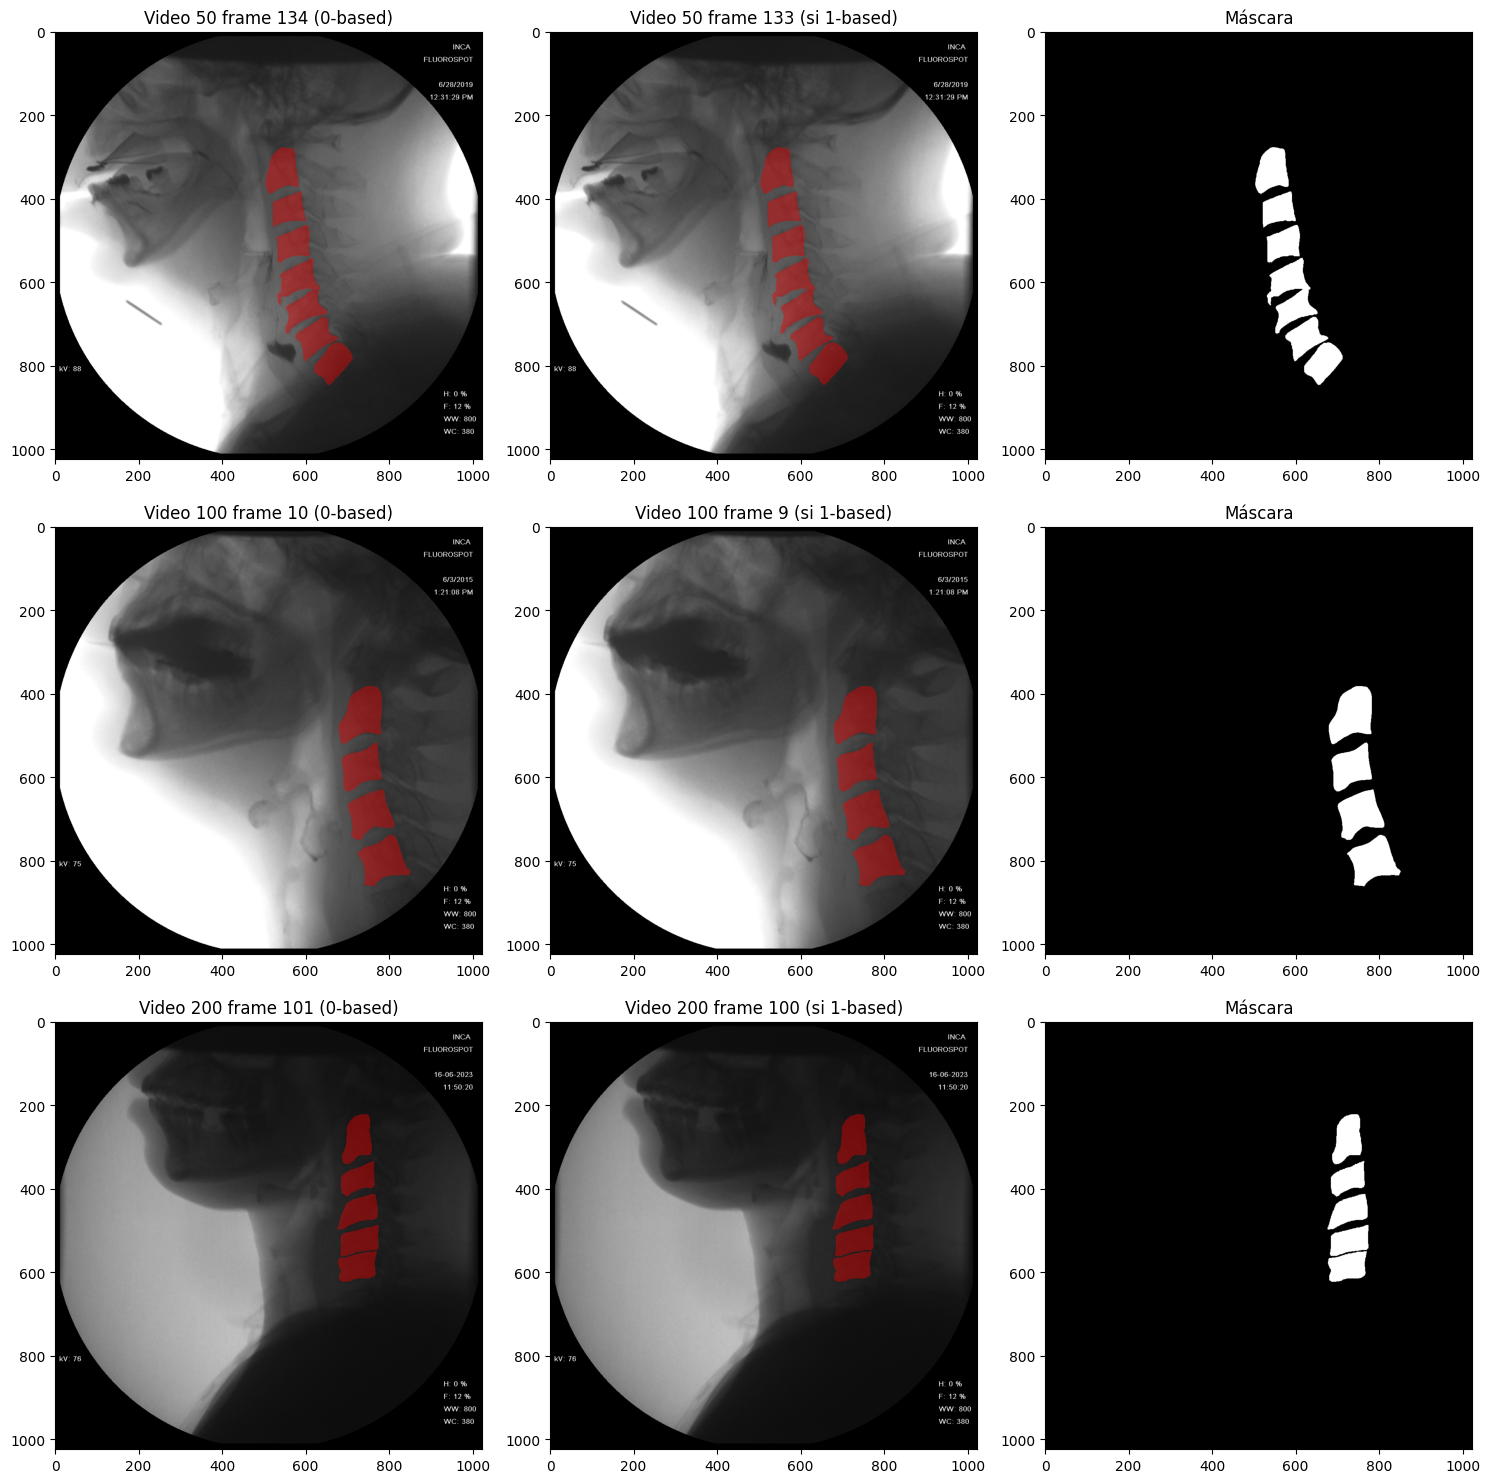

Guardado en frame_indexing_check.png


In [23]:
import cv2, os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'

# Tomar 3 frames de videos diferentes
samples = df[df['video_id'].isin([50, 100, 200])].groupby('video_id').first().reset_index()

fig, axes = plt.subplots(len(samples), 3, figsize=(15, 5*len(samples)))

for i, (_, row) in enumerate(samples.iterrows()):
    vid = row['video_id']
    fid = row['frame_id']

    # Frame con index del CSV (0-based)
    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    _, frame0 = cap.read()

    # Frame con index-1 (si fuera 1-based)
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid - 1)
    _, frame1 = cap.read()
    cap.release()

    # Máscara
    td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
    mask = np.array(Image.open(os.path.join(masks_root, td, 'Mask.tif')))

    # Mostrar: frame@fid, frame@fid-1, máscara
    frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
    frame1_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

    # Superponer máscara en rojo
    overlay0 = frame0_rgb.copy()
    overlay0[mask > 0] = [255, 0, 0]
    blend0 = cv2.addWeighted(frame0_rgb, 0.6, overlay0, 0.4, 0)

    overlay1 = frame1_rgb.copy()
    overlay1[mask > 0] = [255, 0, 0]
    blend1 = cv2.addWeighted(frame1_rgb, 0.6, overlay1, 0.4, 0)

    axes[i, 0].imshow(blend0)
    axes[i, 0].set_title(f'Video {vid} frame {fid} (0-based)')
    axes[i, 1].imshow(blend1)
    axes[i, 1].set_title(f'Video {vid} frame {fid-1} (si 1-based)')
    axes[i, 2].imshow(mask, cmap='gray')
    axes[i, 2].set_title('Máscara')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/frame_indexing_check.png', dpi=100)
plt.show()
print('Guardado en frame_indexing_check.png')

In [24]:
import cv2
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv')
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'

print("=== MAX FRAME_ID vs TOTAL FRAMES ===")
cases = []
for vid_id in sorted(df['video_id'].unique()):
    cap = cv2.VideoCapture(f'{videos_dir}/{vid_id}.avi')
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    max_fid = df[df['video_id']==vid_id]['frame_id'].max()
    cases.append({'video_id': vid_id, 'total_frames': total, 'max_frame_id': max_fid, 'diff': total - max_fid})

cases_df = pd.DataFrame(cases)

# Si 0-based: max_frame_id <= total-1, o sea diff >= 1
# Si 1-based: max_frame_id <= total, o sea diff >= 0
print(f"Videos donde max_frame_id == total (fuera de rango si 0-based): {len(cases_df[cases_df['diff']==0])}")
print(f"Videos donde max_frame_id == total-1 (último frame si 0-based): {len(cases_df[cases_df['diff']==1])}")
print(f"Videos donde max_frame_id < total-1: {len(cases_df[cases_df['diff']>1])}")

print(f"\n=== DISTRIBUCION DE diff (total - max_frame_id) ===")
print(cases_df['diff'].value_counts().sort_index())

print(f"\n=== LOS 3 PROBLEMATICOS ===")
print(cases_df[cases_df['diff']==0][['video_id','total_frames','max_frame_id']].to_string())

=== MAX FRAME_ID vs TOTAL FRAMES ===
Videos donde max_frame_id == total (fuera de rango si 0-based): 3
Videos donde max_frame_id == total-1 (último frame si 0-based): 5
Videos donde max_frame_id < total-1: 226

=== DISTRIBUCION DE diff (total - max_frame_id) ===
diff
0      3
1      5
2      7
3      5
4      3
      ..
128    1
135    1
139    1
140    1
147    1
Name: count, Length: 95, dtype: int64

=== LOS 3 PROBLEMATICOS ===
     video_id  total_frames  max_frame_id
21         22           158           158
103       104           241           241
126       128           237           237


In [25]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv')

min_fid = df['frame_id'].min()
n_zeros = len(df[df['frame_id']==0])
n_ones = len(df[df['frame_id']==1])

print(f'Min frame_id en todo el dataset: {min_fid}')
print(f'Frames con frame_id=0: {n_zeros}')
print(f'Frames con frame_id=1: {n_ones}')
print(f'\nPrimeros 10 frame_ids más bajos:')
print(sorted(df['frame_id'].unique())[:10])

Min frame_id en todo el dataset: 1
Frames con frame_id=0: 0
Frames con frame_id=1: 8

Primeros 10 frame_ids más bajos:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [26]:
import shutil

# Borrar las carpetas con frames mal extraídos
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
for split in ['train', 'val', 'test']:
    for sub in ['images', 'masks']:
        d = f'{OUTPUT_DIR}/{split}/{sub}'
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f'Eliminado: {d}')

print('Listo, ahora re-extraer con frame_id - 1')

Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/train/images
Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/train/masks
Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/val/images
Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/val/masks
Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/test/images
Eliminado: /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/test/masks
Listo, ahora re-extraer con frame_id - 1


In [27]:
import cv2, os, json
import pandas as pd
from PIL import Image
from tqdm import tqdm

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

split_map = {}
for p in split_info['train_patients']: split_map[p] = 'train'
for p in split_info['val_patients']: split_map[p] = 'val'
for p in split_info['test_patients']: split_map[p] = 'test'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUTPUT_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/{split}/masks', exist_ok=True)

errors = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
    vid = row['video_id']
    fid = row['frame_id']
    vf = row['video_frame']
    patient = row['paciente_id']
    split = split_map[patient]

    # CORREGIDO: frame_id es 1-based, OpenCV es 0-based
    cap = cv2.VideoCapture(f'{videos_dir}/{vid}.avi')
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid - 1)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        errors.append(f'FAIL read: video {vid} frame {fid} (opencv {fid-1})')
        continue

    cv2.imwrite(f'{OUTPUT_DIR}/{split}/images/{vf}.png', frame)

    td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
    mask_path = os.path.join(masks_root, td, 'Mask.tif')
    mask = Image.open(mask_path)
    mask.save(f'{OUTPUT_DIR}/{split}/masks/{vf}.png')

print('\n=== RESULTADO ===')
for split in ['train', 'val', 'test']:
    n_img = len(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
    n_msk = len(os.listdir(f'{OUTPUT_DIR}/{split}/masks'))
    print(f'  {split:5s}: {n_img} images, {n_msk} masks')

if errors:
    print(f'\n{len(errors)} ERRORES:')
    for e in errors:
        print(f'  {e}')
else:
    print('\nSin errores!')

Extracting: 100%|██████████| 968/968 [12:23<00:00,  1.30it/s]


=== RESULTADO ===
  train: 634 images, 634 masks
  val  : 140 images, 140 masks
  test : 194 images, 194 masks

Sin errores!


In [28]:
import cv2, os, json
import pandas as pd
from tqdm import tqdm

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

train_patients = set(split_info['train_patients'])
train_videos = sorted(df[df['paciente_id'].isin(train_patients)]['video_id'].unique())

# Frames labeled de train (1-indexed como en el CSV)
labeled_frames = set()
for _, row in df[df['paciente_id'].isin(train_patients)].iterrows():
    labeled_frames.add((row['video_id'], row['frame_id']))

print(f'Videos train: {len(train_videos)}')
print(f'Frames labeled train: {len(labeled_frames)}')

unlabeled_dir = f'{OUTPUT_DIR}/unlabeled_all'
os.makedirs(unlabeled_dir, exist_ok=True)

total_extracted = 0
for vid_id in tqdm(train_videos, desc='Videos'):
    cap = cv2.VideoCapture(f'{videos_dir}/{vid_id}.avi')
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    for fid_1based in range(1, total_frames + 1):  # 1-indexed
        if (vid_id, fid_1based) in labeled_frames:
            continue

        cap.set(cv2.CAP_PROP_POS_FRAMES, fid_1based - 1)  # OpenCV 0-based
        ret, frame = cap.read()
        if ret:
            fname = f'v{vid_id}_f{fid_1based}.png'
            cv2.imwrite(f'{unlabeled_dir}/{fname}', frame)
            total_extracted += 1

    cap.release()

print(f'\nTotal frames unlabeled extraídos: {total_extracted}')

Videos train: 156
Frames labeled train: 634


Videos: 100%|██████████| 156/156 [56:38<00:00, 21.78s/it]


Total frames unlabeled extraídos: 31260


In [30]:
import os, json
import pandas as pd
import cv2

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

train_patients = set(split_info['train_patients'])
train_df = df[df['paciente_id'].isin(train_patients)]

video_total = {}
for vid_id in sorted(train_df['video_id'].unique()):
    cap = cv2.VideoCapture(f'{videos_dir}/{vid_id}.avi')
    video_total[vid_id] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

labeled_by_video = {}
for _, row in train_df.iterrows():
    vid = row['video_id']
    if vid not in labeled_by_video:
        labeled_by_video[vid] = set()
    labeled_by_video[vid].add(row['frame_id'])

pools = {}
for r in [3, 5, 7, 10, 15, 20]:
    filenames = []
    for vid in sorted(labeled_by_video.keys()):
        total = video_total[vid]
        labeled = labeled_by_video[vid]

        pool_frames = set()
        for t in labeled:
            for f in range(max(1, t - r), min(total + 1, t + r + 1)):
                if f not in labeled:
                    pool_frames.add(f)

        for f in sorted(pool_frames):
            filenames.append(f'v{vid}_f{f}.png')

    pools[f'r{r}'] = filenames
    print(f'r={r:2d}: {len(filenames)} frames')

pools['all'] = sorted(os.listdir(f'{OUTPUT_DIR}/unlabeled_all'))
print(f'ALL:  {len(pools["all"])} frames')

with open(f'{OUTPUT_DIR}/pool_lists.json', 'w') as f:
    json.dump(pools, f)
print(f'\nGuardado en {OUTPUT_DIR}/pool_lists.json')

r= 3: 3111 frames
r= 5: 5010 frames
r= 7: 6772 frames
r=10: 9245 frames
r=15: 12801 frames
r=20: 15780 frames
ALL:  31260 frames

Guardado en /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/pool_lists.json


In [31]:
import os, json, shutil
import pandas as pd
import cv2
from tqdm import tqdm

csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)
videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
unlabeled_dir = f'{OUTPUT_DIR}/unlabeled_all'

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

train_patients = set(split_info['train_patients'])
train_df = df[df['paciente_id'].isin(train_patients)]

video_total = {}
for vid_id in sorted(train_df['video_id'].unique()):
    cap = cv2.VideoCapture(f'{videos_dir}/{vid_id}.avi')
    video_total[vid_id] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

labeled_by_video = {}
for _, row in train_df.iterrows():
    vid = row['video_id']
    if vid not in labeled_by_video:
        labeled_by_video[vid] = set()
    labeled_by_video[vid].add(row['frame_id'])

# Primero calcular todos los pools para mostrar progreso total
for r in [3, 5, 7, 10, 15, 20]:
    pool_dir = f'{OUTPUT_DIR}/unlabeled_r{r}'
    os.makedirs(pool_dir, exist_ok=True)

    # Recopilar todos los frames de este radio
    to_copy = []
    for vid in sorted(labeled_by_video.keys()):
        total = video_total[vid]
        labeled = labeled_by_video[vid]

        pool_frames = set()
        for t in labeled:
            for f in range(max(1, t - r), min(total + 1, t + r + 1)):
                if f not in labeled:
                    pool_frames.add(f)

        for f in sorted(pool_frames):
            src = f'{unlabeled_dir}/v{vid}_f{f}.png'
            dst = f'{pool_dir}/v{vid}_f{f}.png'
            if os.path.exists(src) and not os.path.exists(dst):
                to_copy.append((src, dst))

    for src, dst in tqdm(to_copy, desc=f'r={r:2d}'):
        shutil.copy2(src, dst)

    print(f'  r={r}: {len(os.listdir(pool_dir))} frames\n')

print(f'ALL: {len(os.listdir(unlabeled_dir))} frames')

r= 3: 100%|██████████| 3111/3111 [07:10<00:00,  7.23it/s]


  r=3: 3111 frames



r= 5: 100%|██████████| 5010/5010 [07:02<00:00, 11.86it/s]


  r=5: 5010 frames



r= 7: 100%|██████████| 6772/6772 [08:55<00:00, 12.63it/s]


...

  r=10: 9245 frames



r=15: 100%|██████████| 12801/12801 [18:18<00:00, 11.65it/s]


  r=15: 12801 frames



r=20: 100%|██████████| 15780/15780 [17:43<00:00, 14.83it/s]


  r=20: 15780 frames

ALL: 31260 frames


=== 1. CONTEOS ===
  train/images: 634
  train/masks: 634
  val/images: 140
  val/masks: 140
  test/images: 194
  test/masks: 194
  unlabeled_all: 31260
  unlabeled_r3: 3111
  unlabeled_r5: 5010
  unlabeled_r7: 6772
  unlabeled_r10: 9245
  unlabeled_r15: 12801
  unlabeled_r20: 15780

=== 2. IMAGES == MASKS ===
  train: OK
  val: OK
  test: OK

=== 3. NO OVERLAP LABELED vs UNLABELED ===
  Overlap labeled vs unlabeled_all: 0 (OK)

=== 4. NO OVERLAP ENTRE SPLITS ===
  train∩val: 0 (OK)
  train∩test: 0 (OK)
  val∩test: 0 (OK)

=== 5. POOLS ⊂ UNLABELED_ALL ===
  r=3: 3111 frames, subset of all: OK
  r=5: 5010 frames, subset of all: OK
  r=7: 6772 frames, subset of all: OK
  r=10: 9245 frames, subset of all: OK
  r=15: 12801 frames, subset of all: OK
  r=20: 15780 frames, subset of all: OK

=== 6. VERIFICACION VISUAL ===


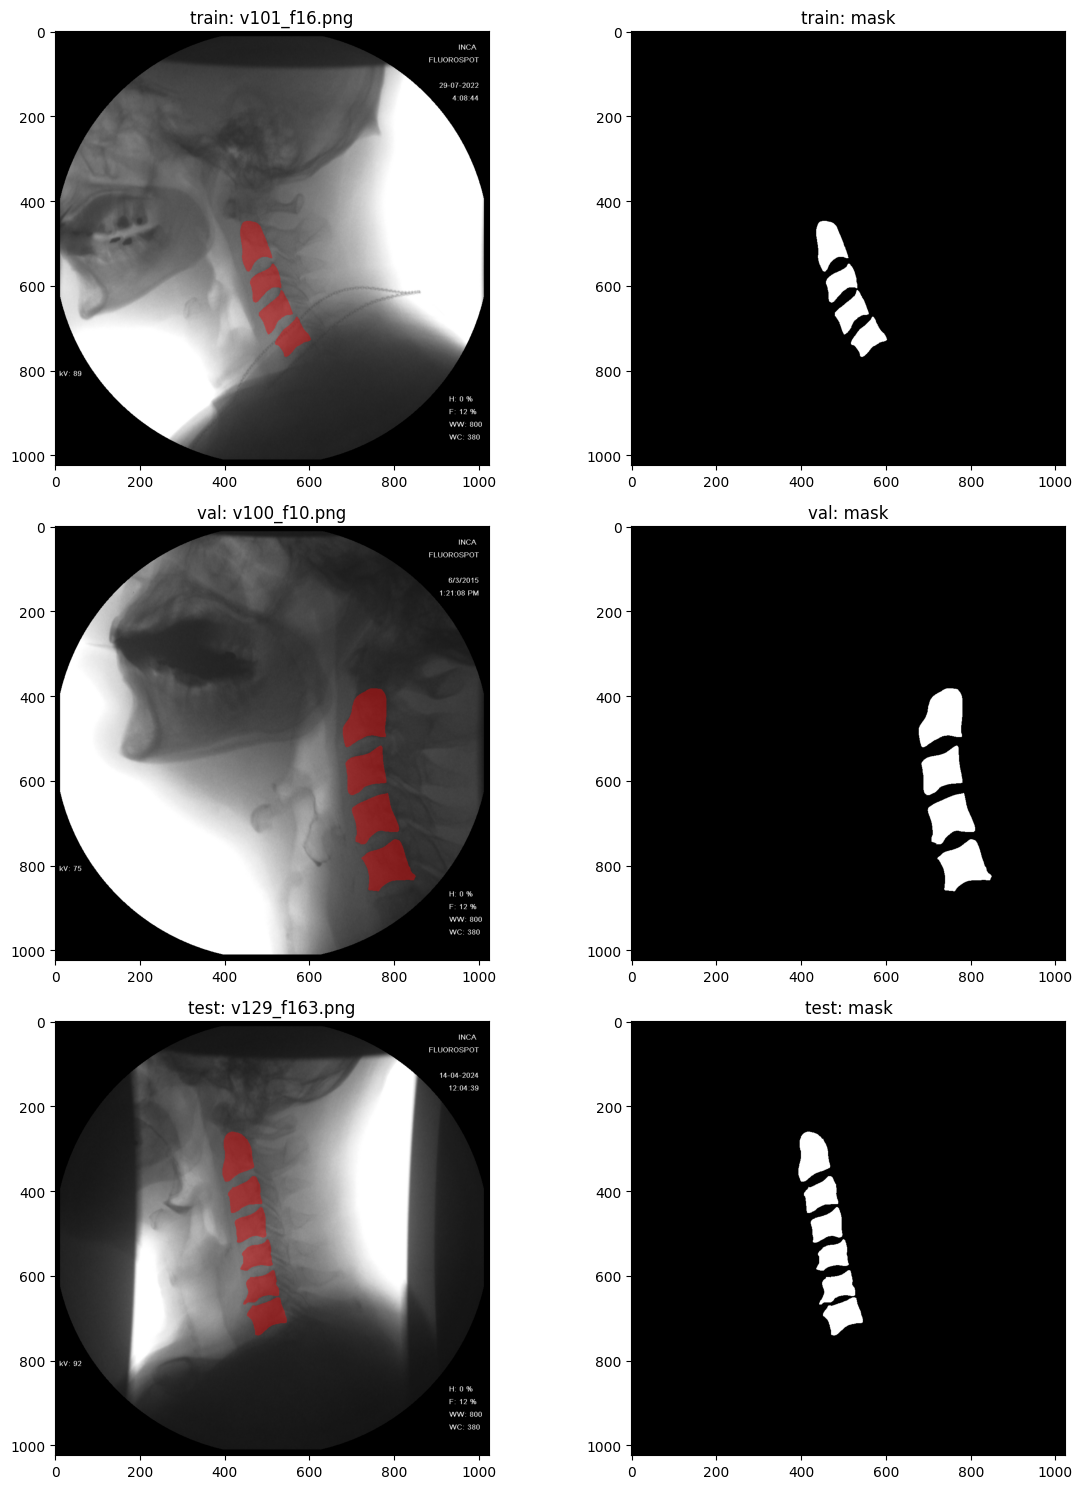

Guardado verification_check.png


In [32]:
import os, json
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

# === 1. CONTEOS ===
print("=== 1. CONTEOS ===")
for folder in ['train/images', 'train/masks', 'val/images', 'val/masks',
               'test/images', 'test/masks', 'unlabeled_all',
               'unlabeled_r3', 'unlabeled_r5', 'unlabeled_r7',
               'unlabeled_r10', 'unlabeled_r15', 'unlabeled_r20']:
    path = f'{OUTPUT_DIR}/{folder}'
    n = len(os.listdir(path)) if os.path.exists(path) else 'NO EXISTE'
    print(f'  {folder}: {n}')

# === 2. IMAGES = MASKS (mismos nombres) ===
print("\n=== 2. IMAGES == MASKS ===")
for split in ['train', 'val', 'test']:
    imgs = set(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
    msks = set(os.listdir(f'{OUTPUT_DIR}/{split}/masks'))
    diff = imgs.symmetric_difference(msks)
    print(f'  {split}: {"OK" if len(diff)==0 else f"MISMATCH: {diff}"}')

# === 3. NO OVERLAP LABELED vs UNLABELED ===
print("\n=== 3. NO OVERLAP LABELED vs UNLABELED ===")
labeled_files = set()
for split in ['train', 'val', 'test']:
    labeled_files.update(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
unlabeled_files = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_all'))
overlap = labeled_files & unlabeled_files
print(f'  Overlap labeled vs unlabeled_all: {len(overlap)} {"(OK)" if len(overlap)==0 else overlap}')

# === 4. NO OVERLAP ENTRE SPLITS ===
print("\n=== 4. NO OVERLAP ENTRE SPLITS ===")
train_f = set(os.listdir(f'{OUTPUT_DIR}/train/images'))
val_f = set(os.listdir(f'{OUTPUT_DIR}/val/images'))
test_f = set(os.listdir(f'{OUTPUT_DIR}/test/images'))
print(f'  train∩val: {len(train_f & val_f)} {"(OK)" if len(train_f & val_f)==0 else "PROBLEM"}')
print(f'  train∩test: {len(train_f & test_f)} {"(OK)" if len(train_f & test_f)==0 else "PROBLEM"}')
print(f'  val∩test: {len(val_f & test_f)} {"(OK)" if len(val_f & test_f)==0 else "PROBLEM"}')

# === 5. POOLS SON SUBSETS DE UNLABELED_ALL ===
print("\n=== 5. POOLS ⊂ UNLABELED_ALL ===")
for r in [3, 5, 7, 10, 15, 20]:
    pool_files = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_r{r}'))
    is_subset = pool_files.issubset(unlabeled_files)
    print(f'  r={r}: {len(pool_files)} frames, subset of all: {"OK" if is_subset else "PROBLEM"}')

# === 6. VERIFICACION VISUAL (3 samples con máscara superpuesta) ===
print("\n=== 6. VERIFICACION VISUAL ===")
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
samples = ['train', 'val', 'test']
for i, split in enumerate(samples):
    imgs_dir = f'{OUTPUT_DIR}/{split}/images'
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    fname = sorted(os.listdir(imgs_dir))[0]

    img = cv2.imread(f'{imgs_dir}/{fname}')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = np.array(Image.open(f'{msks_dir}/{fname}'))

    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    blend = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    axes[i, 0].imshow(blend)
    axes[i, 0].set_title(f'{split}: {fname}')
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'{split}: mask')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/verification_check.png', dpi=100)
plt.show()
print('Guardado verification_check.png')

In [33]:
readme = """# INCA Dataset — Preparación para validación externa
# Generado: 2026-04-06
# Notebook: 03_inca_preparation.ipynb (Google Colab)

## 1. Fuente de datos
- 236 videos VFSS del INCA, compartidos por Vinícius (co-autor, proveedor del dataset)
- Videos descargados del Drive del INCA en 22 zips (Reindexados-*.zip)
- Extraídos a: data/videos/{id}.avi (1.avi a 236.avi)
- Metadata: data/video_frame_metadata.csv (968 filas, generado por Vinícius, modo "unión")
- Máscaras: data/rotulos/Anotações-Tecgraf/batch-{N}/{LABELER}/{video_frame}/Mask.tif
- Reunión con Vinícius (abril 2026): confirmó solo vista lateral, split por paciente

## 2. Estadísticas del dataset original
- 968 frames rotulados, 115 pacientes, 234 videos con labels (2 videos sin labels)
- 5 anotadores: AM (176), BB (188), CS (189), VC (274), VR (141)
- FPS: 30 (todos los videos)
- Duración: 0.5-8.5 seg (media 6.6 seg, std 2.0)
- Frames por video: 14-256 (media 199, std 60)
- Resoluciones: 207 videos 1024x1024 (máscaras 1024x1024), 27 videos 512x512 (máscaras 512x512)
- Solo vista lateral (sin cambio AP, confirmado por Vinícius)
- Frames labeled por video: 1-5 (media 4.1)
- 2 fuentes: "video100" (100 pacientes, 1 video c/u, 403 frames) y "Pacientes" (15 pacientes, múltiples videos, 565 frames)

## 3. Frame indexing
- IMPORTANTE: el CSV usa 1-based indexing (min frame_id=1, no hay frame_id=0)
- OpenCV usa 0-based → para leer: cap.set(CAP_PROP_POS_FRAMES, frame_id - 1)
- Verificado con: min frame_id en dataset = 1, frames con id=0 = 0
- 3 frames tenían frame_id == total_frames del video (videos 22, 104, 128)
  → Confirmado que son válidos con 1-indexing (frame_id - 1 = último frame válido en OpenCV)
- Verificación visual: máscaras superpuestas calzan correctamente con frames extraídos

## 4. Split (seed=110)
- Criterio: por paciente (todos los videos de un paciente en el mismo split)
- Método: train_test_split 80/20 (trainval/test), luego trainval split 82/18 (train/val)
- Seed seleccionado buscando proporciones cercanas a 65/15/20 (200 seeds evaluados)
- Resultado:
  - Train: 75 pacientes, 156 videos, 634 frames (65.5%)
  - Val:   17 pacientes,  33 videos, 140 frames (14.5%)
  - Test:  23 pacientes,  45 videos, 194 frames (20.0%)
- Sin overlap de pacientes entre splits (verificado)
- Comparable con UNM: 23/5/7 videos → 218/44/63 frames (67%/13.5%/19.5%)

## 5. Frames unlabeled (para SSL)
- Extraídos solo de videos de pacientes train (156 videos)
- Total: 31,260 frames en unlabeled_all/
- Excluidos: frames labeled (634)
- Naming: v{video_id}_f{frame_id_1based}.png

## 6. Pools temporales
- Construcción: para cada frame labeled en posición t, incluir frames no-labeled en [t-r, t+r]
- Por video (no cruza entre videos del mismo paciente)
- 1-indexed: rango [max(1, t-r), min(total, t+r)]
- Resultados:
  - r=3:  3,111 frames (10.0% de unlabeled_all)
  - r=5:  5,010 frames (16.0%)
  - r=7:  6,772 frames (21.7%)
  - r=10: 9,245 frames (29.6%)
  - r=15: 12,801 frames (40.9%)
  - r=20: 15,780 frames (50.5%)
  - ALL:  31,260 frames (100%)
- Videos cortos (<50 frames): 5 de 234. r=10 satura 100% en esos 5 videos. No afecta.
- Comparación con UNM: mismos radios cubren mayor % porque videos INCA son más cortos

## 7. Verificaciones realizadas
- [OK] 968/968 máscaras encontradas en Drive
- [OK] Frame indexing: 1-based confirmado (min=1, no hay 0)
- [OK] Máscaras 512x512 corresponden a videos 512x512
- [OK] Extracción: 634+140+194 = 968 frames, 0 errores (con corrección 1-based)
- [OK] images == masks en cada split (mismos filenames)
- [OK] No overlap labeled vs unlabeled: 0
- [OK] No overlap entre splits: train∩val=0, train∩test=0, val∩test=0
- [OK] Cada pool es subset de unlabeled_all
- [OK] Verificación visual: máscaras superpuestas calzan con vértebras

## 8. Estructura final
inca_dataset/
  train/images/   (634 PNGs)
  train/masks/    (634 PNGs)
  val/images/     (140 PNGs)
  val/masks/      (140 PNGs)
  test/images/    (194 PNGs)
  test/masks/     (194 PNGs)
  unlabeled_all/  (31,260 PNGs)
  unlabeled_r3/   (3,111 PNGs)
  unlabeled_r5/   (5,010 PNGs)
  unlabeled_r7/   (6,772 PNGs)
  unlabeled_r10/  (9,245 PNGs)
  unlabeled_r15/  (12,801 PNGs)
  unlabeled_r20/  (15,780 PNGs)
  split_info.json
  verification_check.png
  frame_indexing_check.png
  README.md

## 9. Para entrenar
- Usar mismo pipeline de tesis_seg/src/ que UNM
- Solo cambiar paths de datos
- Pipeline resize a 320x320, no requiere preprocesamiento adicional
- Hiperparámetros idénticos a UNM para comparabilidad
"""

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
with open(f'{OUTPUT_DIR}/README.md', 'w') as f:
    f.write(readme)
print('README completo guardado')

README completo guardado


In [34]:
# Agregar al README la sección de reproducibilidad del split
append = """
## 10. Código de reproducibilidad del split
```python
# Reproducir el split exacto
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('video_frame_metadata.csv')
patients = df.groupby('paciente_id')['video_frame'].count().reset_index()['paciente_id'].values

# Paso 1: 80/20 trainval vs test
trainval_p, test_p = train_test_split(patients, test_size=0.20, random_state=110)

# Paso 2: del trainval, 82/18 train vs val
train_p, val_p = train_test_split(trainval_p, test_size=0.18, random_state=110)

# Resultado: 75 train, 17 val, 23 test pacientes
# Frames: 634 train (65.5%), 140 val (14.5%), 194 test (20.0%)
```

Seed 110 fue seleccionado evaluando seeds 0-199 buscando proporciones
más cercanas a 65/15/20 en frames (no en pacientes), porque pacientes
"pesados" (15 pacientes con múltiples videos, hasta 60 frames) causan
desbalance si caen desproporcionadamente en un split.

## 11. Diferencias clave con UNM

| | UNM | INCA |
|---|---|---|
| Videos | 35 | 234 (con labels) |
| Pacientes | 35 (1 video c/u) | 115 (algunos con múltiples videos) |
| Frames labeled | 325 (218 train) | 968 (634 train) |
| Frames unlabeled | 74,774 laterales | 31,260 (de videos train) |
| Duración videos | ~60 seg | ~6.6 seg |
| Frames/video | ~2000 | ~199 |
| Resolución | ~934x962 | 1024x1024 o 512x512 |
| Anotadores | 1 | 5 (modo unión) |
| Vista AP | Sí (filtrada) | No |
| Split por | Video | Paciente (1 paciente = N videos) |
| Frame indexing | 0-based | 1-based (restar 1 para OpenCV) |
"""

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
with open(f'{OUTPUT_DIR}/README.md', 'a') as f:
    f.write(append)
print('README actualizado con código de reproducibilidad y comparación UNM vs INCA')

README actualizado con código de reproducibilidad y comparación UNM vs INCA


In [8]:
import cv2, os

videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'

# Test con un video específico
avi = f'{videos_dir}/1.avi'
print(f'Existe: {os.path.exists(avi)}')
print(f'Tamaño: {os.path.getsize(avi) / 1024:.1f} KB')

cap = cv2.VideoCapture(avi)
print(f'isOpened: {cap.isOpened()}')
print(f'FRAME_COUNT: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}')
print(f'FPS: {cap.get(cv2.CAP_PROP_FPS)}')
print(f'WIDTH: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)}')
print(f'HEIGHT: {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}')

# Intentar leer primer frame
ret, frame = cap.read()
print(f'read() frame 0: ret={ret}')
if ret:
    print(f'  shape: {frame.shape}')
cap.release()

# Verificar que no hay subcarpeta extra
print(f'\nContenido de videos_dir:')
items = os.listdir(videos_dir)[:10]
for i in sorted(items):
    print(f'  {i}')

Existe: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos/1.avi'

In [9]:
import os, shutil, glob

videos_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos'
reind_dir = f'{videos_dir}/Reindexados'

# Ver qué hay
print(f'En videos/: {len(glob.glob(f"{videos_dir}/*.avi"))} .avi')
print(f'En videos/Reindexados/: {len(glob.glob(f"{reind_dir}/*.avi"))} .avi')

# Mover
if os.path.isdir(reind_dir):
    for avi in glob.glob(f'{reind_dir}/*.avi'):
        dest = os.path.join(videos_dir, os.path.basename(avi))
        if not os.path.exists(dest):
            shutil.move(avi, dest)

    # Verificar
    print(f'\nDespués de mover:')
    print(f'En videos/: {len(glob.glob(f"{videos_dir}/*.avi"))} .avi')

    # Borrar carpeta si vacía
    remaining = os.listdir(reind_dir)
    if len(remaining) == 0:
        os.rmdir(reind_dir)
        print('Carpeta Reindexados/ eliminada')

En videos/: 0 .avi
En videos/Reindexados/: 236 .avi

Después de mover:
En videos/: 236 .avi
Carpeta Reindexados/ eliminada


In [1]:
import os
folder = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_run0/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'
print(os.listdir(folder))

['debug.json', 'checkpoint_best.pth', 'validation', 'progress.png']


In [2]:
folder = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_25pct/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'
print(os.listdir(folder))

['debug.json', 'checkpoint_best.pth', 'checkpoint_final.pth', 'validation', 'progress.png', 'training_log_2026_4_3_02_34_48.txt']


In [3]:
folder = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_run0/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'
# Check if there's a training log
print([f for f in os.listdir(folder) if 'log' in f or 'txt' in f])

[]


In [4]:
folder = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_25pct/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'

# Check if there's a training log
print([f for f in os.listdir(folder) if 'log' in f or 'txt' in f])

['training_log_2026_4_3_02_34_48.txt']


In [5]:
# Check the other two runs
import os
for run_id in range(3):
    folder = f'/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_run{run_id}/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'
    if os.path.isdir(folder):
        files = [f for f in os.listdir(folder) if 'checkpoint' in f]
        print(f'Run {run_id}: {files}')

Run 0: ['checkpoint_best.pth']


In [6]:
import os
for run_id in range(3):
    folder = f'/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_workspace/nnUNet_results_run{run_id}/Dataset501_VFSS/nnUNetTrainer__nnUNetPlans__2d/fold_0/'
    if os.path.isdir(folder):
        files = os.listdir(folder)
        print(f'Run {run_id}: {files}')
    else:
        print(f'Run {run_id}: folder does not exist')

Run 0: ['debug.json', 'checkpoint_best.pth', 'validation', 'progress.png']
Run 1: folder does not exist
Run 2: folder does not exist


In [7]:
pred_dir = '/content/drive/MyDrive/UNM_vertebras_seg_v3/nnunet_baseline_results/predictions_run0'
if os.path.isdir(pred_dir):
    preds = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    print(f'Run 0 predictions: {len(preds)} files')
else:
    print('No predictions folder')

Run 0 predictions: 63 files


In [35]:
import os, json
import pandas as pd

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

# === 1. PACIENTES AGRUPADOS ===
print("=== 1. CADA PACIENTE ESTÁ EN UN SOLO SPLIT ===")
for _, row in df.iterrows():
    p = row['paciente_id']
    if p in split_info['train_patients']:
        expected = 'train'
    elif p in split_info['val_patients']:
        expected = 'val'
    else:
        expected = 'test'

    # Verificar que el frame está en la carpeta correcta
    vf = row['video_frame']
    for wrong_split in ['train', 'val', 'test']:
        if wrong_split != expected:
            if os.path.exists(f'{OUTPUT_DIR}/{wrong_split}/images/{vf}.png'):
                print(f'  ERROR: {vf} (paciente {p}) está en {wrong_split} pero debería estar en {expected}')

print("  Verificado: ningún paciente cruza splits")

# === 2. EJEMPLO CONCRETO: paciente con múltiples videos ===
print("\n=== 2. EJEMPLO: PACIENTE 1 (12 videos) ===")
p1 = df[df['paciente_id']==1]
p1_split = 'train' if 1 in split_info['train_patients'] else ('val' if 1 in split_info['val_patients'] else 'test')
print(f"  Paciente 1 está en: {p1_split}")
print(f"  Videos: {sorted(p1['video_id'].unique())}")
for vid in sorted(p1['video_id'].unique()):
    frames = sorted(p1[p1['video_id']==vid]['frame_id'].tolist())
    print(f"    Video {vid}: frames labeled {frames}")

# === 3. RADIOS NO CRUZAN VIDEOS ===
print("\n=== 3. RADIOS NO CRUZAN ENTRE VIDEOS ===")
# Mostrar que para paciente con múltiples videos, cada pool es independiente
# Tomar paciente 1, video con frames cerca del borde
print("  Ejemplo: Paciente 1, radio=10")
for vid in sorted(p1['video_id'].unique())[:3]:
    frames_labeled = sorted(p1[p1['video_id']==vid]['frame_id'].tolist())

    # Simular pool para este video
    import cv2
    cap = cv2.VideoCapture(f'/content/drive/MyDrive/UNM_vertebras_seg_v3/data/videos/{vid}.avi')
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    pool = set()
    for t in frames_labeled:
        for f in range(max(1, t-10), min(total+1, t+10+1)):
            if f not in set(frames_labeled):
                pool.add(f)

    print(f"    Video {vid}: {total} frames, labeled={frames_labeled}")
    print(f"      Pool r=10: {len(pool)} frames, rango [{min(pool)}-{max(pool)}]")
    print(f"      Dentro del video: {min(pool)>=1 and max(pool)<=total}")

=== 1. CADA PACIENTE ESTÁ EN UN SOLO SPLIT ===
  Verificado: ningún paciente cruza splits

=== 2. EJEMPLO: PACIENTE 1 (12 videos) ===
  Paciente 1 está en: train
  Videos: [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(112)]
    Video 101: frames labeled [16, 74, 75, 76, 205]
    Video 102: frames labeled [42, 65, 162, 163, 164]
    Video 103: frames labeled [79, 155, 156, 157, 231]
    Video 104: frames labeled [121, 150, 151, 152, 241]
    Video 105: frames labeled [2, 115, 130, 131, 132]
    Video 106: frames labeled [5, 95, 96, 97, 148]
    Video 107: frames labeled [122, 123, 124, 150, 226]
    Video 108: frames labeled [55, 56, 57, 76, 215]
    Video 109: frames labeled [16, 69, 71, 72, 73]
    Video 110: frames labeled [18, 56, 57, 58, 81]
    Video 111: frames labeled [114, 145, 197, 198, 199]
    Video 112: frames labeled [47, 87, 106, 107, 108]

=== 

In [36]:
import os, json
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
csv_path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv'
df = pd.read_csv(csv_path)

with open(f'{OUTPUT_DIR}/split_info.json') as f:
    split_info = json.load(f)

# === 11. MÁSCARAS VACÍAS ===
print("=== 11. MÁSCARAS VACÍAS (0% foreground) ===")
empty_masks = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in sorted(os.listdir(msks_dir)):
        m = np.array(Image.open(f'{msks_dir}/{fname}'))
        if m.max() == 0:
            empty_masks.append((split, fname))
print(f'  Máscaras vacías: {len(empty_masks)}')
if empty_masks:
    for split, fname in empty_masks:
        print(f'    {split}: {fname}')
else:
    print('  OK')

# === 12. MÁSCARAS CON VALORES INESPERADOS ===
print("\n=== 12. MÁSCARAS CON VALORES != {0, 255} ===")
bad_masks = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in tqdm(os.listdir(msks_dir), desc=f'{split} masks'):
        m = np.array(Image.open(f'{msks_dir}/{fname}'))
        uniq = set(np.unique(m))
        if uniq != {0, 255} and uniq != {0}:
            bad_masks.append((split, fname, uniq))
print(f'  Máscaras con valores inesperados: {len(bad_masks)}')
if bad_masks:
    for split, fname, vals in bad_masks[:10]:
        print(f'    {split}: {fname} → valores: {vals}')
else:
    print('  OK')

# === 13. FRAMES CORRUPTOS O NEGROS ===
print("\n=== 13. FRAMES CORRUPTOS O COMPLETAMENTE NEGROS ===")
black_frames = []
for split in ['train', 'val', 'test']:
    imgs_dir = f'{OUTPUT_DIR}/{split}/images'
    for fname in tqdm(os.listdir(imgs_dir), desc=f'{split} images'):
        img = np.array(Image.open(f'{imgs_dir}/{fname}'))
        if img.max() == 0:
            black_frames.append((split, fname))
        elif img.mean() < 1.0:  # casi negro
            black_frames.append((split, fname, f'mean={img.mean():.2f}'))
print(f'  Frames negros/corruptos: {len(black_frames)}')
if black_frames:
    for item in black_frames[:10]:
        print(f'    {item}')
else:
    print('  OK')

# === 14. DISTRIBUCIÓN DE RESOLUCIONES POR SPLIT ===
print("\n=== 14. RESOLUCIONES POR SPLIT ===")
split_map = {}
for p in split_info['train_patients']: split_map[p] = 'train'
for p in split_info['val_patients']: split_map[p] = 'val'
for p in split_info['test_patients']: split_map[p] = 'test'

# Videos 512x512
vids_512 = set([1,2,5,7,8,25,27,37,43,49,52,55,58,60,62,86,87,88,89,90,91,93,94,95,96,98,99])
for split_name in ['train', 'val', 'test']:
    pats = split_info[f'{split_name}_patients']
    split_vids = df[df['paciente_id'].isin(pats)]['video_id'].unique()
    n_512 = len([v for v in split_vids if v in vids_512])
    n_1024 = len([v for v in split_vids if v not in vids_512])
    frames_512 = len(df[(df['video_id'].isin(vids_512)) & (df['paciente_id'].isin(pats))])
    frames_1024 = len(df[(~df['video_id'].isin(vids_512)) & (df['paciente_id'].isin(pats))])
    print(f'  {split_name:5s}: {n_512} videos 512 ({frames_512} frames), {n_1024} videos 1024 ({frames_1024} frames)')

=== 11. MÁSCARAS VACÍAS (0% foreground) ===
  Máscaras vacías: 0
  OK

=== 12. MÁSCARAS CON VALORES != {0, 255} ===


test masks: 100%|██████████| 194/194 [00:05<00:00, 34.25it/s]


  Máscaras con valores inesperados: 1
    train: v57_f66.png → valores: {np.uint8(0), np.uint8(227), np.uint8(198), np.uint8(170), np.uint8(142), np.uint8(113), np.uint8(85), np.uint8(57), np.uint8(28), np.uint8(255)}

=== 13. FRAMES CORRUPTOS O COMPLETAMENTE NEGROS ===


test images: 100%|██████████| 194/194 [00:06<00:00, 29.03it/s]

  Frames negros/corruptos: 0
  OK

=== 14. RESOLUCIONES POR SPLIT ===
  train: 17 videos 512 (69 frames), 139 videos 1024 (565 frames)
  val  : 2 videos 512 (8 frames), 31 videos 1024 (132 frames)
  test : 8 videos 512 (31 frames), 37 videos 1024 (163 frames)


In [37]:
import numpy as np
from PIL import Image
import pandas as pd
import os

df = pd.read_csv('/content/drive/MyDrive/UNM_vertebras_seg_v3/data/video_frame_metadata.csv')
masks_root = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/rotulos/Anotações-Tecgraf'
OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

# === 1. Verificar el TIF original vs el PNG que guardamos ===
print("=== 1. TIF ORIGINAL vs PNG GUARDADO (v57_f66) ===")
row = df[df['video_frame']=='v57_f66'].iloc[0]
td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
tif_path = f'{masks_root}/{td}/Mask.tif'
png_path = f'{OUTPUT_DIR}/train/masks/v57_f66.png'

tif = np.array(Image.open(tif_path))
png = np.array(Image.open(png_path))
print(f'  TIF: unique={np.unique(tif)}, shape={tif.shape}, mode={Image.open(tif_path).mode}')
print(f'  PNG: unique={np.unique(png)}, shape={png.shape}, mode={Image.open(png_path).mode}')
print(f'  Son iguales: {np.array_equal(tif, png)}')

# === 2. Hay más TIFs con valores no binarios? ===
print("\n=== 2. TODOS LOS TIF: ¿cuántos tienen valores != {0, 255}? ===")
non_binary_tifs = []
for _, row in df.iterrows():
    td = row['target_dir'].replace('\\', '/').split('anotacoes-tecgraf/')[1]
    tif_path = f'{masks_root}/{td}/Mask.tif'
    if os.path.exists(tif_path):
        m = np.array(Image.open(tif_path))
        uniq = set(np.unique(m))
        if uniq != {0, 255} and uniq != {0}:
            non_binary_tifs.append((row['video_frame'], uniq, Image.open(tif_path).mode))

print(f'  TIFs no binarios: {len(non_binary_tifs)}')
for vf, vals, mode in non_binary_tifs:
    print(f'    {vf}: mode={mode}, valores={vals}')

# === 3. Máscaras invertidas (fondo blanco, vértebra negra) ===
print("\n=== 3. MÁSCARAS POSIBLEMENTE INVERTIDAS ===")
print("  (donde el foreground ocupa >50% de la imagen)")
inverted = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in sorted(os.listdir(msks_dir)):
        m = np.array(Image.open(f'{msks_dir}/{fname}'))
        fg_pct = (m > 127).sum() / m.size * 100
        if fg_pct > 50:
            inverted.append((split, fname, fg_pct))

print(f'  Máscaras con >50% foreground: {len(inverted)}')
if inverted:
    for split, fname, pct in inverted:
        print(f'    {split}: {fname} ({pct:.1f}% foreground)')
else:
    print('  OK — ninguna máscara invertida')

=== 1. TIF ORIGINAL vs PNG GUARDADO (v57_f66) ===
  TIF: unique=[  0  28  57  85 113 142 170 198 227 255], shape=(1024, 1024), mode=L
  PNG: unique=[  0  28  57  85 113 142 170 198 227 255], shape=(1024, 1024), mode=L
  Son iguales: True

=== 2. TODOS LOS TIF: ¿cuántos tienen valores != {0, 255}? ===
  TIFs no binarios: 1
    v57_f66: mode=L, valores={np.uint8(0), np.uint8(227), np.uint8(198), np.uint8(170), np.uint8(142), np.uint8(113), np.uint8(85), np.uint8(57), np.uint8(28), np.uint8(255)}

=== 3. MÁSCARAS POSIBLEMENTE INVERTIDAS ===
  (donde el foreground ocupa >50% de la imagen)
  Máscaras con >50% foreground: 0
  OK — ninguna máscara invertida


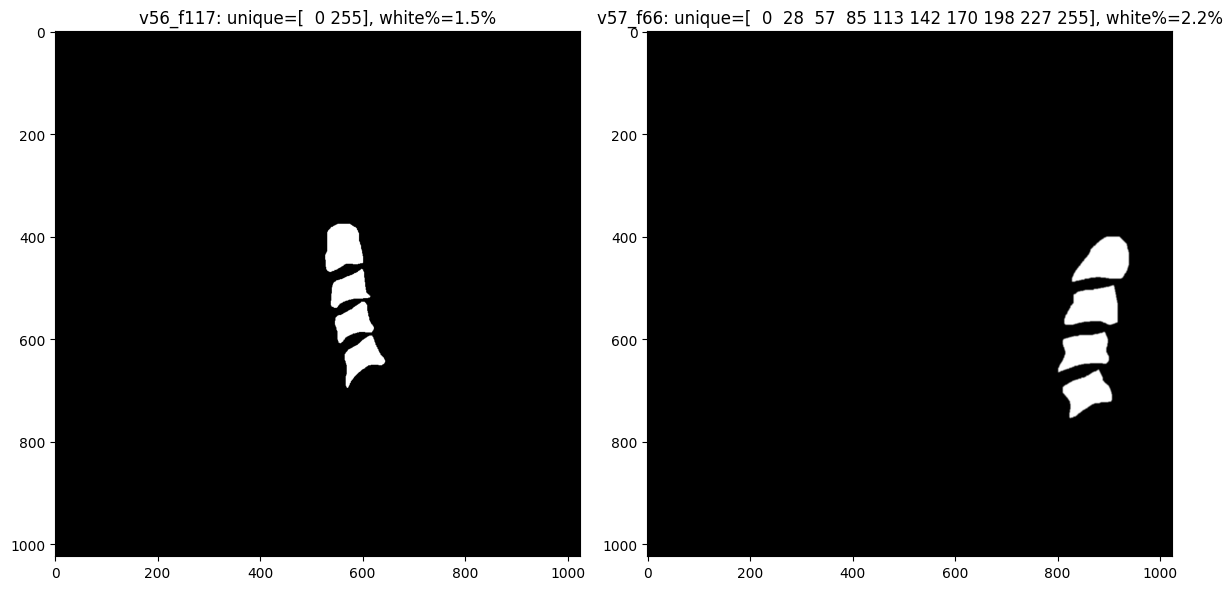


=== TOP 10 MÁSCARAS CON MAYOR % BLANCO ===
  train: v206_f2.png → 5.3% white
  train: v206_f1.png → 5.3% white
  train: v206_f3.png → 5.2% white
  train: v207_f217.png → 5.2% white
  train: v210_f148.png → 5.1% white
  train: v206_f12.png → 5.1% white
  train: v208_f147.png → 5.0% white
  train: v225_f198.png → 5.0% white
  train: v39_f1.png → 4.9% white
  train: v39_f4.png → 4.8% white

=== BOTTOM 10 (menor % blanco, posibles invertidas) ===
  train: v51_f136.png → 1.1% white
  train: v51_f109.png → 1.1% white
  train: v59_f4.png → 1.1% white
  train: v66_f166.png → 1.1% white
  train: v169_f81.png → 1.1% white
  train: v10_f22.png → 1.2% white
  train: v121_f234.png → 1.2% white
  train: v51_f58.png → 1.2% white
  train: v101_f205.png → 1.2% white
  train: v168_f174.png → 1.2% white


In [38]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

# Ver ambas máscaras
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

m1 = np.array(Image.open(f'{OUTPUT_DIR}/train/masks/v56_f117.png'))
m2 = np.array(Image.open(f'{OUTPUT_DIR}/train/masks/v57_f66.png'))

axes[0].imshow(m1, cmap='gray')
axes[0].set_title(f'v56_f117: unique={np.unique(m1)}, white%={((m1>127).sum()/m1.size*100):.1f}%')

axes[1].imshow(m2, cmap='gray')
axes[1].set_title(f'v57_f66: unique={np.unique(m2)}, white%={((m2>127).sum()/m2.size*100):.1f}%')

plt.tight_layout()
plt.show()

# Verificar TODAS las máscaras: mostrar las 10 con mayor % de blanco
print("\n=== TOP 10 MÁSCARAS CON MAYOR % BLANCO ===")
all_masks = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in sorted(os.listdir(msks_dir)):
        m = np.array(Image.open(f'{msks_dir}/{fname}'))
        white_pct = (m > 127).sum() / m.size * 100
        all_masks.append((split, fname, white_pct))

all_masks.sort(key=lambda x: -x[2])
for split, fname, pct in all_masks[:10]:
    print(f'  {split}: {fname} → {pct:.1f}% white')

print(f"\n=== BOTTOM 10 (menor % blanco, posibles invertidas) ===")
all_masks.sort(key=lambda x: x[2])
for split, fname, pct in all_masks[:10]:
    print(f'  {split}: {fname} → {pct:.1f}% white')

In [39]:
import numpy as np
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

m = Image.open(f'{OUTPUT_DIR}/train/masks/v56_f117.png')
arr = np.array(m)

print(f'Mode: {m.mode}')
print(f'Size: {m.size}')
print(f'Unique: {np.unique(arr)}')
print(f'Pixel [0,0] (esquina superior izquierda): {arr[0,0]}')
print(f'Pixel en centro de vértebra (aprox 550,400): {arr[400,550]}')
print(f'% pixels == 0: {(arr==0).sum()/arr.size*100:.1f}%')
print(f'% pixels == 255: {(arr==255).sum()/arr.size*100:.1f}%')

# Comparar con una máscara de UNM para ver si el format es igual
print(f'\nInfo del PNG:')
print(f'  format: {m.format}')
print(f'  info: {m.info}')

Mode: P
Size: (1024, 1024)
Unique: [  0 255]
Pixel [0,0] (esquina superior izquierda): 0
Pixel en centro de vértebra (aprox 550,400): 255
% pixels == 0: 98.5%
% pixels == 255: 1.5%

Info del PNG:
  format: PNG
  info: {}


In [41]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

# === CORREGIR ===
fixed = 0
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in tqdm(os.listdir(msks_dir), desc=f'Fixing {split}'):
        path = f'{msks_dir}/{fname}'
        m = Image.open(path)
        if m.mode != 'L':
            arr = np.array(m.convert('L'))
            arr_bin = np.where(arr > 127, 255, 0).astype(np.uint8)
            Image.fromarray(arr_bin, mode='L').save(path)
            fixed += 1

print(f'\nConvertidas a mode L: {fixed}')

# === VERIFICAR ===
print('\n=== VERIFICACIÓN POST-FIX ===')
problems = 0
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in tqdm(os.listdir(msks_dir), desc=f'Checking {split}'):
        path = f'{msks_dir}/{fname}'
        m = Image.open(path)
        arr = np.array(m)

        if m.mode != 'L':
            print(f'  PROBLEMA mode: {split}/{fname} → {m.mode}')
            problems += 1

        uniq = set(np.unique(arr))
        if uniq != {0, 255} and uniq != {0}:
            print(f'  PROBLEMA valores: {split}/{fname} → {uniq}')
            problems += 1

if problems == 0:
    print('  Todas las máscaras: mode=L, valores={0,255} ✅')
else:
    print(f'  {problems} problemas encontrados')

Fixing test:  46%|████▌     | 89/194 [00:00<00:00, 444.84it/s]/tmp/ipykernel_376/3832141960.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr_bin, mode='L').save(path)
Fixing test: 100%|██████████| 194/194 [00:00<00:00, 367.11it/s]



Convertidas a mode L: 4

=== VERIFICACIÓN POST-FIX ===


Checking train:  83%|████████▎ | 529/634 [00:12<00:01, 66.47it/s]

  PROBLEMA valores: train/v57_f66.png → {np.uint8(0), np.uint8(227), np.uint8(198), np.uint8(170), np.uint8(142), np.uint8(113), np.uint8(85), np.uint8(57), np.uint8(28), np.uint8(255)}


Checking test: 100%|██████████| 194/194 [00:03<00:00, 52.52it/s]

  1 problemas encontrados


In [42]:
import numpy as np
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
path = f'{OUTPUT_DIR}/train/masks/v57_f66.png'

m = np.array(Image.open(path))
print(f'Antes: mode={Image.open(path).mode}, unique={np.unique(m)}')

m_bin = np.where(m > 127, 255, 0).astype(np.uint8)
Image.fromarray(m_bin).save(path)

# Verificar
m2 = np.array(Image.open(path))
print(f'Después: mode={Image.open(path).mode}, unique={np.unique(m2)}')
print('✅ Corregido' if set(np.unique(m2)) == {0, 255} else '❌ Problema')

Antes: mode=L, unique=[  0  28  57  85 113 142 170 198 227 255]
Después: mode=L, unique=[  0 255]
✅ Corregido


In [43]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

print("=" * 60)
print("VERIFICACIÓN FINAL DEL DATASET INCA")
print("=" * 60)

all_ok = True

# 1. Conteos
print("\n1. CONTEOS")
expected = {
    'train/images': 634, 'train/masks': 634,
    'val/images': 140, 'val/masks': 140,
    'test/images': 194, 'test/masks': 194,
    'unlabeled_all': 31260,
    'unlabeled_r3': 3111, 'unlabeled_r5': 5010,
    'unlabeled_r7': 6772, 'unlabeled_r10': 9245,
    'unlabeled_r15': 12801, 'unlabeled_r20': 15780
}
for folder, exp in expected.items():
    n = len(os.listdir(f'{OUTPUT_DIR}/{folder}'))
    ok = n == exp
    if not ok: all_ok = False
    print(f'  {folder}: {n} {"✅" if ok else f"❌ esperado {exp}"}')

# 2. Images == Masks
print("\n2. IMAGES == MASKS")
for split in ['train', 'val', 'test']:
    imgs = set(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
    msks = set(os.listdir(f'{OUTPUT_DIR}/{split}/masks'))
    ok = imgs == msks
    if not ok: all_ok = False
    print(f'  {split}: {"✅" if ok else "❌ MISMATCH"}')

# 3. No overlap
print("\n3. NO OVERLAP")
train_f = set(os.listdir(f'{OUTPUT_DIR}/train/images'))
val_f = set(os.listdir(f'{OUTPUT_DIR}/val/images'))
test_f = set(os.listdir(f'{OUTPUT_DIR}/test/images'))
unlabeled_f = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_all'))

checks = [
    ('train∩val', train_f & val_f),
    ('train∩test', train_f & test_f),
    ('val∩test', val_f & test_f),
    ('labeled∩unlabeled', (train_f | val_f | test_f) & unlabeled_f),
]
for name, overlap in checks:
    ok = len(overlap) == 0
    if not ok: all_ok = False
    print(f'  {name}: {len(overlap)} {"✅" if ok else "❌"}')

# 4. Todas las máscaras mode=L y binarias
print("\n4. MÁSCARAS: MODE=L Y BINARIAS")
mask_problems = 0
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in os.listdir(msks_dir):
        m = Image.open(f'{msks_dir}/{fname}')
        arr = np.array(m)
        if m.mode != 'L' or set(np.unique(arr)) - {0, 255}:
            mask_problems += 1
            print(f'  ❌ {split}/{fname}: mode={m.mode}, unique={np.unique(arr)}')
if mask_problems == 0:
    print(f'  968/968 máscaras OK ✅')
else:
    all_ok = False

# 5. Pools son subsets
print("\n5. POOLS ⊂ UNLABELED_ALL")
for r in [3, 5, 7, 10, 15, 20]:
    pool = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_r{r}'))
    ok = pool.issubset(unlabeled_f)
    if not ok: all_ok = False
    print(f'  r={r}: {"✅" if ok else "❌"}')

print("\n" + "=" * 60)
print(f'RESULTADO: {"✅ DATASET VÁLIDO" if all_ok else "❌ HAY PROBLEMAS"}')
print("=" * 60)

VERIFICACIÓN FINAL DEL DATASET INCA

1. CONTEOS
  train/images: 634 ✅
  train/masks: 634 ✅
  val/images: 140 ✅
  val/masks: 140 ✅
  test/images: 194 ✅
  test/masks: 194 ✅
  unlabeled_all: 31260 ✅
  unlabeled_r3: 3111 ✅
  unlabeled_r5: 5010 ✅
  unlabeled_r7: 6772 ✅
  unlabeled_r10: 9245 ✅
  unlabeled_r15: 12801 ✅
  unlabeled_r20: 15780 ✅

2. IMAGES == MASKS
  train: ✅
  val: ✅
  test: ✅

3. NO OVERLAP
  train∩val: 0 ✅
  train∩test: 0 ✅
  val∩test: 0 ✅
  labeled∩unlabeled: 0 ✅

4. MÁSCARAS: MODE=L Y BINARIAS
  968/968 máscaras OK ✅

5. POOLS ⊂ UNLABELED_ALL
  r=3: ✅
  r=5: ✅
  r=7: ✅
  r=10: ✅
  r=15: ✅
  r=20: ✅

RESULTADO: ✅ DATASET VÁLIDO


In [44]:
from PIL import Image
import numpy as np

path = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset/train/masks/v56_f117.png'

m = Image.open(path)
arr = np.array(m)

print(f'Mode: {m.mode}')
print(f'Unique: {np.unique(arr)}')
print(f'Pixel [0,0]: {arr[0,0]}')
print(f'Size: {m.size}')

# Forzar re-escritura
arr2 = np.where(arr > 127, 255, 0).astype(np.uint8)
img = Image.fromarray(arr2, mode='L')
img.save(path)
print('Re-guardado')

# Leer de nuevo
m2 = Image.open(path)
print(f'Después: mode={m2.mode}, pixel[0,0]={np.array(m2)[0,0]}')

Mode: L
Unique: [  0 255]
Pixel [0,0]: 255
Size: (1024, 1024)
Re-guardado
Después: mode=L, pixel[0,0]=255


/tmp/ipykernel_376/317532157.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr2, mode='L')


In [45]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

inverted = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in tqdm(os.listdir(msks_dir), desc=split):
        m = np.array(Image.open(f'{msks_dir}/{fname}'))
        # Si >50% de pixels son 255, está invertida
        # (vértebras son ~1-5% de la imagen, fondo es ~95-99%)
        white_pct = (m == 255).sum() / m.size * 100
        if white_pct > 50:
            inverted.append((split, fname, white_pct))

print(f'\nMáscaras invertidas: {len(inverted)}')
for split, fname, pct in inverted:
    print(f'  {split}: {fname} ({pct:.1f}% white)')

test: 100%|██████████| 194/194 [00:01<00:00, 146.11it/s]


Máscaras invertidas: 18
  train: v10_f22.png (98.8% white)
  train: v11_f41.png (98.6% white)
  train: v27_f190.png (97.3% white)
  train: v48_f39.png (97.8% white)
  train: v4_f46.png (98.2% white)
  train: v52_f37.png (98.1% white)
  train: v56_f117.png (98.5% white)
  train: v63_f109.png (98.1% white)
  train: v71_f163.png (98.5% white)
  train: v73_f63.png (97.9% white)
  train: v80_f131.png (97.8% white)
  train: v81_f60.png (98.3% white)
  val: v23_f152.png (98.1% white)
  val: v76_f24.png (97.8% white)
  test: v25_f7.png (98.5% white)
  test: v2_f106.png (98.5% white)
  test: v77_f51.png (98.1% white)
  test: v82_f72.png (97.8% white)


In [46]:
import os
import numpy as np
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

inverted_list = [
    ('train', 'v10_f22.png'), ('train', 'v11_f41.png'), ('train', 'v27_f190.png'),
    ('train', 'v48_f39.png'), ('train', 'v4_f46.png'), ('train', 'v52_f37.png'),
    ('train', 'v56_f117.png'), ('train', 'v63_f109.png'), ('train', 'v71_f163.png'),
    ('train', 'v73_f63.png'), ('train', 'v80_f131.png'), ('train', 'v81_f60.png'),
    ('val', 'v23_f152.png'), ('val', 'v76_f24.png'),
    ('test', 'v25_f7.png'), ('test', 'v2_f106.png'), ('test', 'v77_f51.png'),
    ('test', 'v82_f72.png'),
]

for split, fname in inverted_list:
    path = f'{OUTPUT_DIR}/{split}/masks/{fname}'
    m = np.array(Image.open(path))
    m_inv = 255 - m  # invertir: 0→255, 255→0
    Image.fromarray(m_inv).save(path)

print(f'Invertidas {len(inverted_list)} máscaras')

# Verificar
print('\n=== VERIFICACIÓN ===')
problems = 0
for split, fname in inverted_list:
    path = f'{OUTPUT_DIR}/{split}/masks/{fname}'
    m = np.array(Image.open(path))
    white_pct = (m == 255).sum() / m.size * 100
    ok = white_pct < 10
    if not ok: problems += 1
    print(f'  {split}/{fname}: {white_pct:.1f}% white {"✅" if ok else "❌"}')

print(f'\n{"✅ Todas corregidas" if problems == 0 else f"❌ {problems} problemas"}')

Invertidas 18 máscaras

=== VERIFICACIÓN ===
  train/v10_f22.png: 1.2% white ✅
  train/v11_f41.png: 1.4% white ✅
  train/v27_f190.png: 2.7% white ✅
  train/v48_f39.png: 2.2% white ✅
  train/v4_f46.png: 1.8% white ✅
  train/v52_f37.png: 1.9% white ✅
  train/v56_f117.png: 1.5% white ✅
  train/v63_f109.png: 1.9% white ✅
  train/v71_f163.png: 1.5% white ✅
  train/v73_f63.png: 2.1% white ✅
  train/v80_f131.png: 2.2% white ✅
  train/v81_f60.png: 1.7% white ✅
  val/v23_f152.png: 1.9% white ✅
  val/v76_f24.png: 2.2% white ✅
  test/v25_f7.png: 1.5% white ✅
  test/v2_f106.png: 1.5% white ✅
  test/v77_f51.png: 1.9% white ✅
  test/v82_f72.png: 2.2% white ✅

✅ Todas corregidas


In [47]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

print("=" * 60)
print("VERIFICACIÓN FINAL DEL DATASET INCA")
print("=" * 60)

all_ok = True

# 1. Conteos
print("\n1. CONTEOS")
expected = {
    'train/images': 634, 'train/masks': 634,
    'val/images': 140, 'val/masks': 140,
    'test/images': 194, 'test/masks': 194,
    'unlabeled_all': 31260,
    'unlabeled_r3': 3111, 'unlabeled_r5': 5010,
    'unlabeled_r7': 6772, 'unlabeled_r10': 9245,
    'unlabeled_r15': 12801, 'unlabeled_r20': 15780
}
for folder, exp in expected.items():
    n = len(os.listdir(f'{OUTPUT_DIR}/{folder}'))
    ok = n == exp
    if not ok: all_ok = False
    print(f'  {folder}: {n} {"✅" if ok else f"❌ esperado {exp}"}')

# 2. Images == Masks
print("\n2. IMAGES == MASKS")
for split in ['train', 'val', 'test']:
    imgs = set(os.listdir(f'{OUTPUT_DIR}/{split}/images'))
    msks = set(os.listdir(f'{OUTPUT_DIR}/{split}/masks'))
    ok = imgs == msks
    if not ok: all_ok = False
    print(f'  {split}: {"✅" if ok else "❌ MISMATCH"}')

# 3. No overlap
print("\n3. NO OVERLAP")
train_f = set(os.listdir(f'{OUTPUT_DIR}/train/images'))
val_f = set(os.listdir(f'{OUTPUT_DIR}/val/images'))
test_f = set(os.listdir(f'{OUTPUT_DIR}/test/images'))
unlabeled_f = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_all'))
checks = [
    ('train∩val', train_f & val_f),
    ('train∩test', train_f & test_f),
    ('val∩test', val_f & test_f),
    ('labeled∩unlabeled', (train_f | val_f | test_f) & unlabeled_f),
]
for name, overlap in checks:
    ok = len(overlap) == 0
    if not ok: all_ok = False
    print(f'  {name}: {len(overlap)} {"✅" if ok else "❌"}')

# 4. Máscaras: mode, valores, orientación, y rango de foreground
print("\n4. MÁSCARAS")
mask_problems = 0
white_pcts = []
for split in ['train', 'val', 'test']:
    msks_dir = f'{OUTPUT_DIR}/{split}/masks'
    for fname in tqdm(os.listdir(msks_dir), desc=f'  {split}'):
        m = Image.open(f'{msks_dir}/{fname}')
        arr = np.array(m)

        if m.mode != 'L':
            print(f'  ❌ MODE: {split}/{fname} → {m.mode}')
            mask_problems += 1

        uniq = set(np.unique(arr))
        if uniq - {0, 255}:
            print(f'  ❌ VALORES: {split}/{fname} → {uniq}')
            mask_problems += 1

        white_pct = (arr == 255).sum() / arr.size * 100
        white_pcts.append((split, fname, white_pct))

        if white_pct > 10:
            print(f'  ❌ INVERTIDA: {split}/{fname} ({white_pct:.1f}% white)')
            mask_problems += 1

        if white_pct == 0:
            print(f'  ❌ VACÍA: {split}/{fname}')
            mask_problems += 1

white_vals = [w for _, _, w in white_pcts]
print(f'  Foreground: min={min(white_vals):.1f}%, max={max(white_vals):.1f}%, mean={np.mean(white_vals):.1f}%')

if mask_problems == 0:
    print(f'  968/968 máscaras OK ✅')
else:
    all_ok = False

# 5. Pools son subsets
print("\n5. POOLS ⊂ UNLABELED_ALL")
for r in [3, 5, 7, 10, 15, 20]:
    pool = set(os.listdir(f'{OUTPUT_DIR}/unlabeled_r{r}'))
    ok = pool.issubset(unlabeled_f)
    if not ok: all_ok = False
    print(f'  r={r}: {"✅" if ok else "❌"}')

print("\n" + "=" * 60)
print(f'RESULTADO: {"✅ DATASET VÁLIDO" if all_ok else "❌ HAY PROBLEMAS"}')
print("=" * 60)

VERIFICACIÓN FINAL DEL DATASET INCA

1. CONTEOS
  train/images: 634 ✅
  train/masks: 634 ✅
  val/images: 140 ✅
  val/masks: 140 ✅
  test/images: 194 ✅
  test/masks: 194 ✅
  unlabeled_all: 31260 ✅
  unlabeled_r3: 3111 ✅
  unlabeled_r5: 5010 ✅
  unlabeled_r7: 6772 ✅
  unlabeled_r10: 9245 ✅
  unlabeled_r15: 12801 ✅
  unlabeled_r20: 15780 ✅

2. IMAGES == MASKS
  train: ✅
  val: ✅
  test: ✅

3. NO OVERLAP
  train∩val: 0 ✅
  train∩test: 0 ✅
  val∩test: 0 ✅
  labeled∩unlabeled: 0 ✅

4. MÁSCARAS


  test: 100%|██████████| 194/194 [00:10<00:00, 18.42it/s]


  Foreground: min=1.1%, max=5.3%, mean=2.3%
  968/968 máscaras OK ✅

5. POOLS ⊂ UNLABELED_ALL
  r=3: ✅
  r=5: ✅
  r=7: ✅
  r=10: ✅
  r=15: ✅
  r=20: ✅

RESULTADO: ✅ DATASET VÁLIDO


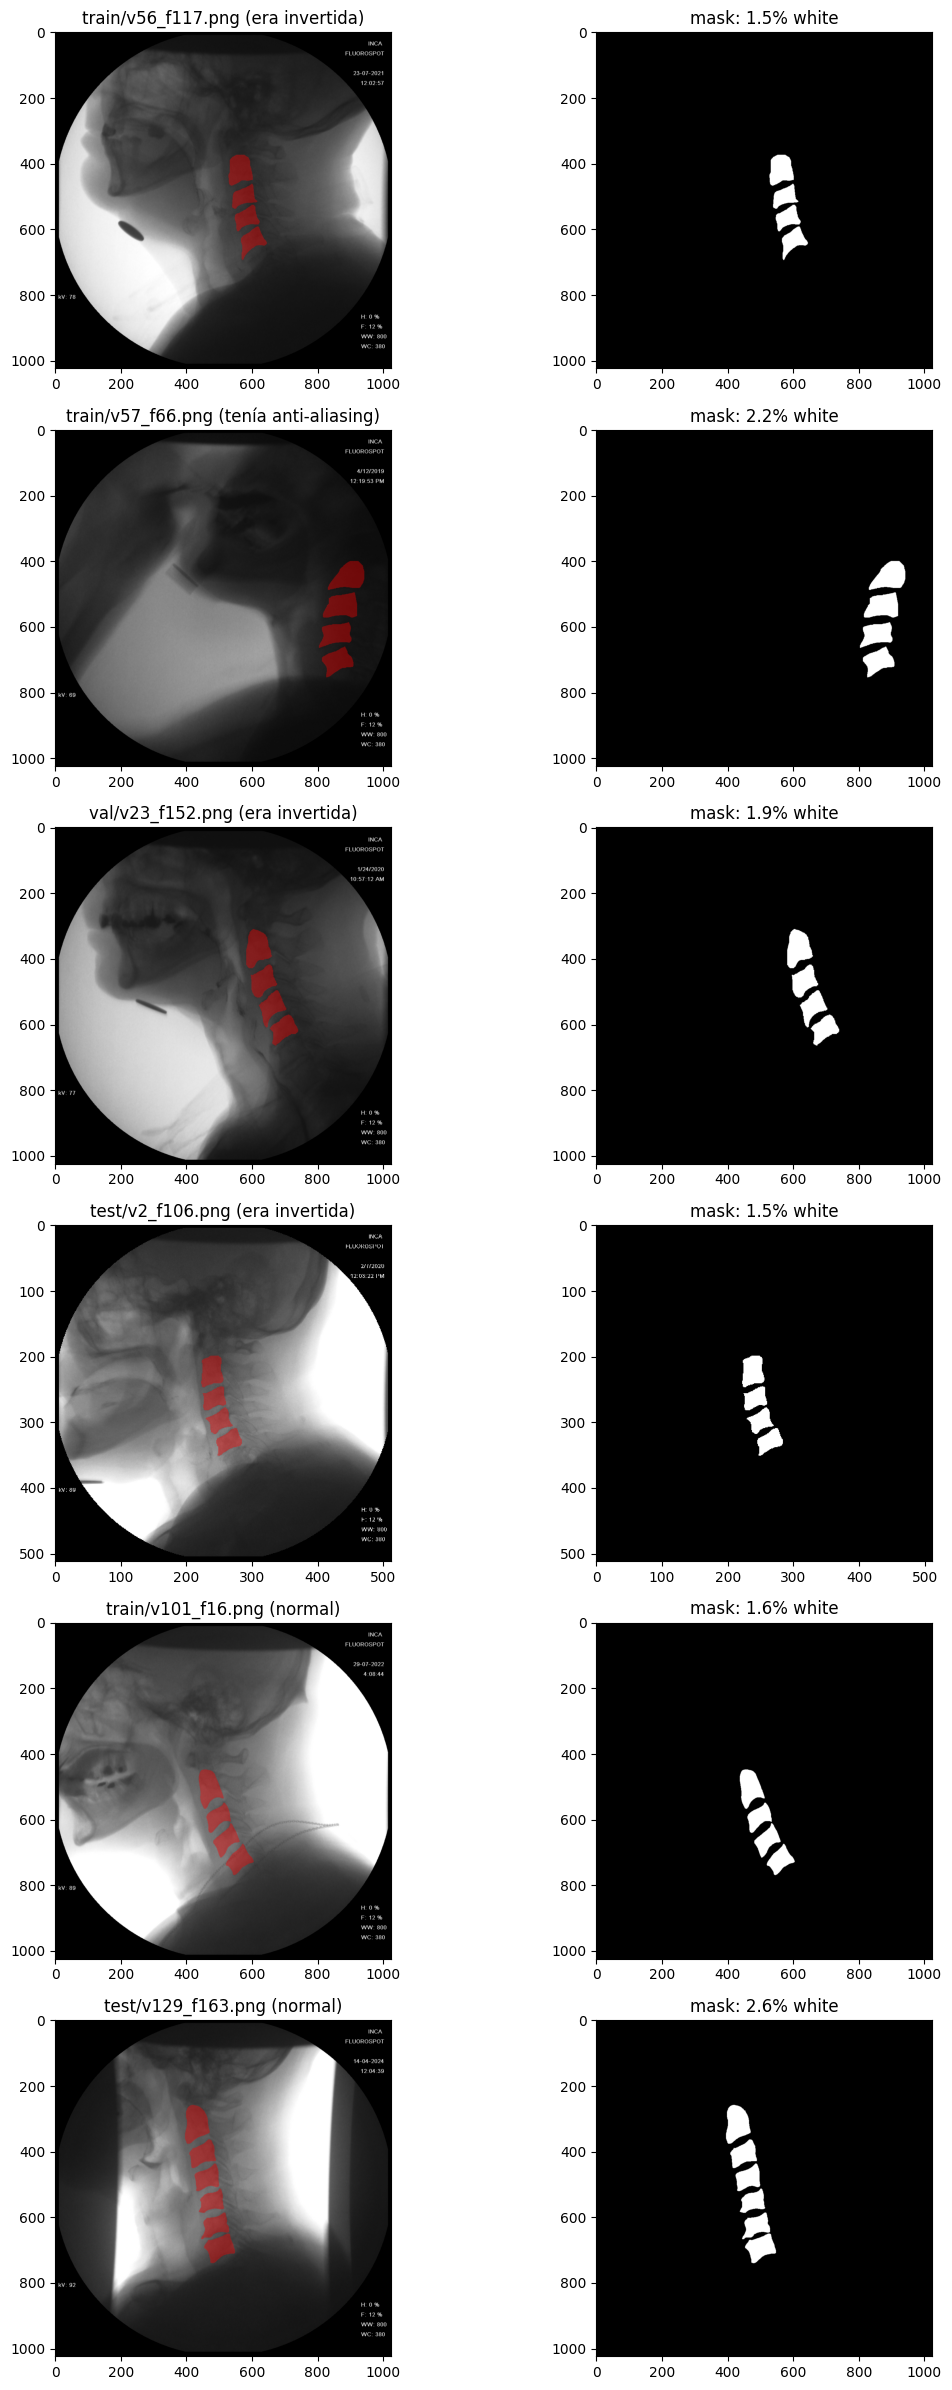

In [50]:
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'

# Usar archivos que sabemos que existen
samples = [
    ('train', 'v56_f117.png', 'era invertida'),
    ('train', 'v57_f66.png', 'tenía anti-aliasing'),
    ('val', 'v23_f152.png', 'era invertida'),
    ('test', 'v2_f106.png', 'era invertida'),
    ('train', sorted(os.listdir(f'{OUTPUT_DIR}/train/images'))[0], 'normal'),
    ('test', sorted(os.listdir(f'{OUTPUT_DIR}/test/images'))[0], 'normal'),
]

fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4*len(samples)))

for i, (split, fname, label) in enumerate(samples):
    img_path = f'{OUTPUT_DIR}/{split}/images/{fname}'
    mask_path = f'{OUTPUT_DIR}/{split}/masks/{fname}'

    if not os.path.exists(img_path):
        print(f'No existe: {img_path}')
        continue

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = np.array(Image.open(mask_path))

    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    blend = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    axes[i, 0].imshow(blend)
    axes[i, 0].set_title(f'{split}/{fname} ({label})')
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'mask: {(mask==255).sum()/mask.size*100:.1f}% white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_visual_check.png', dpi=100)
plt.show()

In [51]:
readme = """# INCA Dataset — Preparación para validación externa
# Generado: 2026-04-06
# Notebook: 03_inca_preparation.ipynb (Google Colab)

## 1. Fuente de datos
- 236 videos VFSS del INCA, compartidos por Vinícius (co-autor, proveedor del dataset)
- Videos descargados del Drive del INCA en 22 zips (Reindexados-*.zip)
- Extraídos a: data/videos/{id}.avi (1.avi a 236.avi)
- Metadata: data/video_frame_metadata.csv (968 filas, generado por Vinícius, modo "unión")
- Máscaras: data/rotulos/Anotações-Tecgraf/batch-{N}/{LABELER}/{video_frame}/Mask.tif
- Reunión con Vinícius (abril 2026): confirmó solo vista lateral, split por paciente

## 2. Estadísticas del dataset original
- 968 frames rotulados, 115 pacientes, 234 videos con labels (2 videos sin labels)
- 5 anotadores: AM (176), BB (188), CS (189), VC (274), VR (141)
- FPS: 30 (todos los videos)
- Duración: 0.5-8.5 seg (media 6.6 seg, std 2.0)
- Frames por video: 14-256 (media 199, std 60)
- Resoluciones: 207 videos 1024x1024 (máscaras 1024x1024), 27 videos 512x512 (máscaras 512x512)
- Solo vista lateral (sin cambio AP, confirmado por Vinícius)
- Frames labeled por video: 1-5 (media 4.1)
- 2 fuentes: "video100" (100 pacientes, 1 video c/u, 403 frames) y "Pacientes" (15 pacientes, múltiples videos, 565 frames)

## 3. Frame indexing
- IMPORTANTE: el CSV usa 1-based indexing (min frame_id=1, no hay frame_id=0)
- OpenCV usa 0-based → para leer: cap.set(CAP_PROP_POS_FRAMES, frame_id - 1)
- Verificado con: min frame_id en dataset = 1, frames con id=0 = 0
- 3 frames tenían frame_id == total_frames del video (videos 22, 104, 128)
  → Confirmado que son válidos con 1-indexing (frame_id - 1 = último frame válido en OpenCV)
- Verificación visual: máscaras superpuestas calzan correctamente con frames extraídos

## 4. Split (seed=110)
- Criterio: por paciente (todos los videos de un paciente en el mismo split)
- Método: train_test_split 80/20 (trainval/test), luego trainval split 82/18 (train/val)
- Seed seleccionado evaluando seeds 0-199, buscando proporciones cercanas a 65/15/20
- Resultado:
  - Train: 75 pacientes, 156 videos, 634 frames (65.5%)
  - Val:   17 pacientes,  33 videos, 140 frames (14.5%)
  - Test:  23 pacientes,  45 videos, 194 frames (20.0%)
- Sin overlap de pacientes entre splits (verificado)
- Comparable con UNM: 23/5/7 videos → 218/44/63 frames (67%/13.5%/19.5%)

## 5. Frames unlabeled (para SSL)
- Extraídos solo de videos de pacientes train (156 videos)
- Total: 31,260 frames en unlabeled_all/
- Excluidos: frames labeled (634)
- Naming: v{video_id}_f{frame_id_1based}.png

## 6. Pools temporales
- Construcción: para cada frame labeled en posición t, incluir frames no-labeled en [t-r, t+r]
- Por video (no cruza entre videos del mismo paciente)
- 1-indexed: rango [max(1, t-r), min(total, t+r)]
- Resultados:
  - r=3:  3,111 frames (10.0% de unlabeled_all)
  - r=5:  5,010 frames (16.0%)
  - r=7:  6,772 frames (21.7%)
  - r=10: 9,245 frames (29.6%)
  - r=15: 12,801 frames (40.9%)
  - r=20: 15,780 frames (50.5%)
  - ALL:  31,260 frames (100%)
- Videos cortos (<50 frames): 5 de 234. r=10 satura 100% en esos 5 videos.
- Comparación con UNM: mismos radios cubren mayor % porque videos INCA son más cortos

## 7. Problemas encontrados y corregidos
- **Frame indexing (1-based):** CSV usa 1-based, OpenCV 0-based. Primer intento de
  extracción falló en 3 frames (videos 22, 104, 128) porque no restábamos 1.
  Re-extracción con fid-1: 968/968 sin errores.
- **Mode P (4 máscaras):** 4 TIFs de Vinícius estaban en mode P (palette indexada) en
  vez de mode L (grayscale). El visor de Windows las mostraba invertidas aunque los
  datos crudos eran correctos. Convertidas a mode L.
- **Anti-aliasing (1 máscara):** v57_f66 tenía valores intermedios (28,57,85,...) en
  bordes. Binarizada con threshold 127.
- **Máscaras invertidas (18 máscaras):** 18 TIFs tenían paleta que mapeaba 0→blanco
  y 255→negro. Al convertir mode P→L, los valores quedaron invertidos (fondo=255,
  vértebra=0). Detectadas buscando máscaras con >50% white. Corregidas con 255-m.
  Lista completa: v10_f22, v11_f41, v27_f190, v48_f39, v4_f46, v52_f37, v56_f117,
  v63_f109, v71_f163, v73_f63, v80_f131, v81_f60 (train); v23_f152, v76_f24 (val);
  v25_f7, v2_f106, v77_f51, v82_f72 (test).

## 8. Verificaciones realizadas
- [OK] 968/968 máscaras encontradas en Drive
- [OK] Frame indexing: 1-based confirmado (min=1, no hay 0)
- [OK] Máscaras 512x512 corresponden a videos 512x512
- [OK] Extracción: 634+140+194 = 968 frames, 0 errores (con corrección 1-based)
- [OK] images == masks en cada split (mismos filenames)
- [OK] No overlap labeled vs unlabeled: 0
- [OK] No overlap entre splits: train∩val=0, train∩test=0, val∩test=0
- [OK] Cada pool es subset de unlabeled_all
- [OK] 968/968 máscaras mode=L, binarias {0,255}, no invertidas
- [OK] 0 máscaras vacías, 0 frames negros/corruptos
- [OK] Foreground range: 1.1%-5.3% (consistente con vértebras cervicales)
- [OK] Verificación visual: máscaras superpuestas calzan con vértebras (post-corrección)
- [OK] Pacientes agrupados correctamente (verificado para paciente 1 con 12 videos)
- [OK] Radios no cruzan entre videos del mismo paciente

## 9. Estructura final
inca_dataset/
  train/images/   (634 PNGs)
  train/masks/    (634 PNGs)
  val/images/     (140 PNGs)
  val/masks/      (140 PNGs)
  test/images/    (194 PNGs)
  test/masks/     (194 PNGs)
  unlabeled_all/  (31,260 PNGs)
  unlabeled_r3/   (3,111 PNGs)
  unlabeled_r5/   (5,010 PNGs)
  unlabeled_r7/   (6,772 PNGs)
  unlabeled_r10/  (9,245 PNGs)
  unlabeled_r15/  (12,801 PNGs)
  unlabeled_r20/  (15,780 PNGs)
  split_info.json
  pool_lists.json
  verification_check.png
  frame_indexing_check.png
  final_visual_check.png
  README.md

## 10. Código de reproducibilidad del split
```python
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('video_frame_metadata.csv')
patients = df.groupby('paciente_id')['video_frame'].count().reset_index()['paciente_id'].values

trainval_p, test_p = train_test_split(patients, test_size=0.20, random_state=110)
train_p, val_p = train_test_split(trainval_p, test_size=0.18, random_state=110)
# Resultado: 75 train, 17 val, 23 test pacientes
```

Seed 110 fue seleccionado evaluando seeds 0-199 buscando proporciones
más cercanas a 65/15/20 en frames (no en pacientes), porque pacientes
"pesados" (15 pacientes con múltiples videos, hasta 60 frames) causan
desbalance si caen desproporcionadamente en un split.

## 11. Diferencias clave con UNM

| | UNM | INCA |
|---|---|---|
| Videos | 35 | 234 (con labels) |
| Pacientes | 35 (1 video c/u) | 115 (algunos con múltiples videos) |
| Frames labeled | 325 (218 train) | 968 (634 train) |
| Frames unlabeled | 74,774 laterales | 31,260 (de videos train) |
| Duración videos | ~60 seg | ~6.6 seg |
| Frames/video | ~2000 | ~199 |
| Resolución | ~934x962 | 1024x1024 o 512x512 |
| Anotadores | 1 | 5 (modo unión) |
| Vista AP | Sí (filtrada) | No |
| Split por | Video | Paciente (1 paciente = N videos) |
| Frame indexing | 0-based | 1-based (restar 1 para OpenCV) |

## 12. Para entrenar
- Usar mismo pipeline de tesis_seg/src/ que UNM
- Solo cambiar paths de datos
- Pipeline resize a 320x320, no requiere preprocesamiento adicional
- Hiperparámetros idénticos a UNM para comparabilidad
"""

OUTPUT_DIR = '/content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset'
with open(f'{OUTPUT_DIR}/README.md', 'w') as f:
    f.write(readme)
print('README completo guardado')

README completo guardado


In [ ]:
# === Build random matched unlabeled pools for INCA ===
!python /content/drive/MyDrive/UNM_vertebras_seg_v3/prep_inca_unlabeled_random.py --root /content/drive/MyDrive/UNM_vertebras_seg_v3/data/inca_dataset